# Sprint Notebook — Final 2-3 Day Push

Baseline: **v7 Platform 0.5636**, OOF 0.6429, M1-5 OOF 0.6515  
Sections: A · B · C · D · E · F · G · H

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import os

SEED       = 42
DATA_DIR   = '../data/'
MODEL_DIR  = '../models/'
SUBMIT_DIR = '../submissions/'

np.random.seed(SEED)
print('Imports OK')

Imports OK


In [3]:
# Load train and test data (needed for month_of_year mask and y)
print('Loading data...')
train_df = pd.read_parquet(f'{DATA_DIR}train_features_tier2.parquet')
test_df  = pd.read_parquet(f'{DATA_DIR}test_features_tier2.parquet')
y = train_df['invalid_ratio'].values
print(f'  Train: {train_df.shape}  Test: {test_df.shape}')
print(f'  Train months: {sorted(train_df["month_of_year"].unique())}')
print(f'  Test  months: {sorted(test_df["month_of_year"].unique())}')

Loading data...
  Train: (6076546, 31)  Test: (2028750, 30)
  Train months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Test  months: [1, 2, 3, 4, 5]


---
## Section A — M1-5 Weight Optimization + Fine-Grained Search

**Rationale**: v7 weights (LGB=0.35, XGB=0.65) were optimised on full 12-month OOF
with step=0.05. The test set is M1-5 only. Re-searching on the M1-5 OOF subset
with finer step=0.01 may find weights that better match the test distribution.

Note: v8a OOF ≡ v7 OOF (step11_gpu.py trains identically to v7; only test-time TE
differs). We use v8a OOF files as the v7 OOF proxy when v7 files are absent.

In [4]:
# ── Load OOF predictions (prefer v7; fall back to v8a which is identical) ────
def load_oof(model, version_primary='v7', version_fallback='v8a'):
    primary  = f'{MODEL_DIR}{model}_oof_{version_primary}.npy'
    fallback = f'{MODEL_DIR}{model}_oof_{version_fallback}.npy'
    if os.path.exists(primary):
        arr = np.load(primary)
        print(f'  Loaded {primary}')
        return arr, version_primary
    elif os.path.exists(fallback):
        arr = np.load(fallback)
        print(f'  Loaded {fallback}  [proxy for {version_primary} — OOF is identical]')
        return arr, version_fallback
    else:
        raise FileNotFoundError(f'Neither {primary} nor {fallback} found.')

print('Loading OOF predictions...')
lgb_oof, lgb_ver = load_oof('lgb')
xgb_oof, xgb_ver = load_oof('xgb')

# CB oof v4 (optional — v7 ensemble gave it weight=0)
cb_oof_path = f'{MODEL_DIR}cb_oof_v4.npy'
cb_oof = np.load(cb_oof_path) if os.path.exists(cb_oof_path) else None
print(f'  CB v4 OOF: {"loaded" if cb_oof is not None else "not found (skip)"}')

lgb_rho = spearmanr(y, lgb_oof)[0]
xgb_rho = spearmanr(y, xgb_oof)[0]
print(f'\nFull OOF Spearman:')
print(f'  LGB ({lgb_ver}): {lgb_rho:.4f}  (expected ~0.6336)')
print(f'  XGB ({xgb_ver}): {xgb_rho:.4f}  (expected ~0.6403)')

Loading OOF predictions...
  Loaded ../models/lgb_oof_v8a.npy  [proxy for v7 — OOF is identical]
  Loaded ../models/xgb_oof_v8a.npy  [proxy for v7 — OOF is identical]
  CB v4 OOF: not found (skip)

Full OOF Spearman:
  LGB (v8a): 0.6336  (expected ~0.6336)
  XGB (v8a): 0.6403  (expected ~0.6403)


In [5]:
# ── M1-5 mask ─────────────────────────────────────────────────────────────────
m15_mask = train_df['month_of_year'].isin([1, 2, 3, 4, 5]).values
print(f'M1-5 train rows: {m15_mask.sum():,} / {len(train_df):,}')

y_m15      = y[m15_mask]
lgb_oof_m15 = lgb_oof[m15_mask]
xgb_oof_m15 = xgb_oof[m15_mask]
cb_oof_m15  = cb_oof[m15_mask] if cb_oof is not None else None

lgb_rho_m15 = spearmanr(y_m15, lgb_oof_m15)[0]
xgb_rho_m15 = spearmanr(y_m15, xgb_oof_m15)[0]
print(f'\nM1-5 OOF Spearman:')
print(f'  LGB: {lgb_rho_m15:.4f}')
print(f'  XGB: {xgb_rho_m15:.4f}')

M1-5 train rows: 2,470,429 / 6,076,546

M1-5 OOF Spearman:
  LGB: 0.6428
  XGB: 0.6482


In [6]:
# ── Fine-grained weight search (step=0.01) on M1-5 OOF ───────────────────────
from itertools import product

weights = np.arange(0, 1.01, 0.01)

best_rho_m15  = -1
best_w_m15    = None

# Search over LGB weight; XGB = 1 - lgb_w (CB=0 as in v7)
results_m15 = []
for lgb_w in weights:
    xgb_w = 1.0 - lgb_w
    pred = lgb_w * lgb_oof_m15 + xgb_w * xgb_oof_m15
    rho  = spearmanr(y_m15, pred)[0]
    results_m15.append((lgb_w, xgb_w, rho))
    if rho > best_rho_m15:
        best_rho_m15 = rho
        best_w_m15   = (lgb_w, xgb_w)

print(f'M1-5 weight search (step=0.01, CB=0) complete.')
print(f'  Best M1-5 weights : LGB={best_w_m15[0]:.2f}, XGB={best_w_m15[1]:.2f}')
print(f'  Best M1-5 OOF Rho : {best_rho_m15:.4f}')
print(f'\n  v7 weights        : LGB=0.35, XGB=0.65')
print(f'  v7 M1-5 OOF (ref) : 0.6515')

# Compare v7 weights on M1-5
pred_v7_m15 = 0.35 * lgb_oof_m15 + 0.65 * xgb_oof_m15
rho_v7_m15  = spearmanr(y_m15, pred_v7_m15)[0]
print(f'  v7 weights applied to M1-5 OOF: {rho_v7_m15:.4f}')
print(f'  Delta (new - v7): {best_rho_m15 - rho_v7_m15:+.4f}')

M1-5 weight search (step=0.01, CB=0) complete.
  Best M1-5 weights : LGB=0.39, XGB=0.61
  Best M1-5 OOF Rho : 0.6515

  v7 weights        : LGB=0.35, XGB=0.65
  v7 M1-5 OOF (ref) : 0.6515
  v7 weights applied to M1-5 OOF: 0.6515
  Delta (new - v7): +0.0000


In [7]:
# ── Also run fine-grained search on FULL OOF for comparison ──────────────────
best_rho_full = -1
best_w_full   = None
results_full  = []
for lgb_w in weights:
    xgb_w = 1.0 - lgb_w
    pred  = lgb_w * lgb_oof + xgb_w * xgb_oof
    rho   = spearmanr(y, pred)[0]
    results_full.append((lgb_w, xgb_w, rho))
    if rho > best_rho_full:
        best_rho_full = rho
        best_w_full   = (lgb_w, xgb_w)

print(f'Full OOF weight search (step=0.01, CB=0) complete.')
print(f'  Best full weights : LGB={best_w_full[0]:.2f}, XGB={best_w_full[1]:.2f}')
print(f'  Best full OOF Rho : {best_rho_full:.4f}')

print(f'\n=== Summary ===')
print(f'  Full-OOF optimal : LGB={best_w_full[0]:.2f}  XGB={best_w_full[1]:.2f}  Rho={best_rho_full:.4f}')
print(f'  M1-5-OOF optimal : LGB={best_w_m15[0]:.2f}  XGB={best_w_m15[1]:.2f}  Rho={best_rho_m15:.4f}')
print(f'  v7 weights       : LGB=0.35   XGB=0.65')

Full OOF weight search (step=0.01, CB=0) complete.
  Best full weights : LGB=0.36, XGB=0.64
  Best full OOF Rho : 0.6429

=== Summary ===
  Full-OOF optimal : LGB=0.36  XGB=0.64  Rho=0.6429
  M1-5-OOF optimal : LGB=0.39  XGB=0.61  Rho=0.6515
  v7 weights       : LGB=0.35   XGB=0.65


In [8]:
# ── Optional: 3-model search including CB (if available) ─────────────────────
if cb_oof is not None:
    best_rho_3m = -1
    best_w_3m   = None
    step = 0.05  # coarser for 3-model to keep it fast
    ws   = np.arange(0, 1.01, step)
    for lgb_w in ws:
        for xgb_w in ws:
            cb_w = round(1.0 - lgb_w - xgb_w, 4)
            if cb_w < 0 or cb_w > 1:
                continue
            pred = lgb_w * lgb_oof_m15 + xgb_w * xgb_oof_m15 + cb_w * cb_oof_m15
            rho  = spearmanr(y_m15, pred)[0]
            if rho > best_rho_3m:
                best_rho_3m = rho
                best_w_3m   = (lgb_w, xgb_w, cb_w)
    print(f'3-model M1-5 search (step=0.05):')
    print(f'  Best: LGB={best_w_3m[0]:.2f}, XGB={best_w_3m[1]:.2f}, CB={best_w_3m[2]:.2f}')
    print(f'  M1-5 Rho: {best_rho_3m:.4f}')
else:
    print('CB OOF not available — skipping 3-model search.')
    best_w_3m = None

CB OOF not available — skipping 3-model search.


In [9]:
# ── Generate ensemble_v12.csv if test predictions are available ───────────────
# Prefer v7 test preds (full-data TE); fall back instructions if missing.

lgb_test_path_v7  = f'{MODEL_DIR}lgb_test_v7.npy'
xgb_test_path_v7  = f'{MODEL_DIR}xgb_test_v7.npy'
lgb_test_path_v8a = f'{MODEL_DIR}lgb_test_v8a.npy'
xgb_test_path_v8a = f'{MODEL_DIR}xgb_test_v8a.npy'

if os.path.exists(lgb_test_path_v7) and os.path.exists(xgb_test_path_v7):
    lgb_test = np.load(lgb_test_path_v7)
    xgb_test = np.load(xgb_test_path_v7)
    test_src  = 'v7 (full-data TE)'
    use_weights = best_w_m15  # apply M1-5 optimised weights
    print(f'Using v7 test predictions ({test_src}).')
elif os.path.exists(lgb_test_path_v8a) and os.path.exists(xgb_test_path_v8a):
    lgb_test = np.load(lgb_test_path_v8a)
    xgb_test = np.load(xgb_test_path_v8a)
    test_src  = 'v8a (M1-5 TE — different from v7!)'
    use_weights = best_w_m15
    print(f'WARNING: v7 test preds not found; using v8a ({test_src}).')
    print('  v8a test TE differs from v7; the v12 submission may not outperform v7.')
    print('  To generate a clean v12, download lgb_test_v7.npy + xgb_test_v7.npy from GPU server.')
else:
    lgb_test = None
    print('ERROR: No test predictions found. Download from GPU server:')
    print('  models/lgb_test_v7.npy')
    print('  models/xgb_test_v7.npy')

if lgb_test is not None:
    lgb_w, xgb_w = use_weights
    test_pred = lgb_w * lgb_test + xgb_w * xgb_test
    test_pred = np.clip(test_pred, 0, 1)

    # Verify shape matches test_df
    assert len(test_pred) == len(test_df), f'Shape mismatch: {len(test_pred)} vs {len(test_df)}'
    assert not np.isnan(test_pred).any(), 'NaN in predictions!'

    out_path = f'{SUBMIT_DIR}ensemble_v12.csv'
    pd.DataFrame({'id': test_df.index, 'invalid_ratio': test_pred}).to_csv(out_path, index=False)
    print(f'\nSaved: {out_path}')
    print(f'  Weights: LGB={lgb_w:.2f}, XGB={xgb_w:.2f}')
    print(f'  Test source: {test_src}')
    print(f'  Rows: {len(test_pred):,}  Min: {test_pred.min():.4f}  Max: {test_pred.max():.4f}')
    print(f'  Expected rows: 2,028,750')

  v8a test TE differs from v7; the v12 submission may not outperform v7.
  To generate a clean v12, download lgb_test_v7.npy + xgb_test_v7.npy from GPU server.

Saved: ../submissions/ensemble_v12.csv
  Weights: LGB=0.39, XGB=0.61
  Test source: v8a (M1-5 TE — different from v7!)
  Rows: 2,028,750  Min: 0.0052  Max: 1.0000
  Expected rows: 2,028,750


---
## Section D — Adversarial Validation + Temporal CV

**Rationale**: Train a classifier to distinguish train vs test data.
If AUC > 0.6, there is a significant distribution shift — predicted "test-likeness"
probabilities can be used as sample weights to align training toward test distribution.

Additionally, Temporal CV (train on M1-4, validate on M5) gives a more realistic
estimate of platform performance than random 5-fold CV.

**Reference**: Ivanescu 2021 (Adversarial Validation), Temporal Shift 2025

### Part 1 — Adversarial Validation

Build a LightGBM classifier: label = 0 (train) / 1 (test).
5-fold CV AUC measures how distinguishable train and test are.

We run **two variants**:
1. **Full train vs test** — captures all shift including the known month difference
2. **M1-5 train vs test** — isolates shift *beyond* the known month restriction

In [10]:
# ── Part 1: Adversarial Validation ────────────────────────────────────────────
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Features for AV: use raw + engineered features, exclude target and IDs
AV_EXCLUDE = ['invalid_ratio', 'grid_lon', 'grid_lat', 'grid_id', 'grid_period']
AV_FEATURES = [c for c in train_df.columns if c not in AV_EXCLUDE]
print(f'AV features ({len(AV_FEATURES)}): {AV_FEATURES}')

# ── Variant 1: Full train (M1-12) vs test (M1-5) ────────────────────────────
# Subsample train to keep runtime manageable (match test size ~2M)
np.random.seed(SEED)
train_sub_idx = np.random.choice(len(train_df), size=len(test_df), replace=False)

X_av = pd.concat([
    train_df.iloc[train_sub_idx][AV_FEATURES].reset_index(drop=True),
    test_df[AV_FEATURES].reset_index(drop=True)
], axis=0, ignore_index=True)
y_av = np.concatenate([np.zeros(len(train_sub_idx)), np.ones(len(test_df))])

print(f'\nVariant 1 — Full train vs test:')
print(f'  Combined: {X_av.shape}  (label=0: {(y_av==0).sum():,}, label=1: {(y_av==1).sum():,})')

av_params = {
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'objective': 'binary',
    'metric': 'auc',
    'verbose': -1,
    'n_jobs': -1,
    'random_state': SEED,
    'n_estimators': 500,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
av1_oof = np.zeros(len(X_av))
av1_aucs = []
av1_importances = np.zeros(len(AV_FEATURES))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_av, y_av)):
    model = lgb.LGBMClassifier(**av_params)
    model.fit(
        X_av.iloc[tr_idx], y_av[tr_idx],
        eval_set=[(X_av.iloc[va_idx], y_av[va_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    av1_oof[va_idx] = model.predict_proba(X_av.iloc[va_idx])[:, 1]
    fold_auc = roc_auc_score(y_av[va_idx], av1_oof[va_idx])
    av1_aucs.append(fold_auc)
    av1_importances += model.feature_importances_
    print(f'  Fold {fold}: AUC = {fold_auc:.4f}  (best_iter={model.best_iteration_})')

av1_mean_auc = np.mean(av1_aucs)
print(f'\n  Mean AUC (Full train vs test): {av1_mean_auc:.4f}')
print(f'  Interpretation: {"STRONG shift — proceed with AV weights" if av1_mean_auc > 0.6 else "Weak shift — AV weights unlikely to help"}')

AV features (26): ['total_count', 'longitude_scaled', 'latitude_scaled', 'Precipitations', 'HauteurNeige', 'Temperature', 'ForceVent', 'day_of_week', 'month_of_year', 'hour', 'log_total_count', 'count_bin', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'grid_te', 'time_period', 'grid_period_te', 'is_raining', 'has_snow', 'grid_avg_count', 'grid_violation_std', 'grid_sample_count']

Variant 1 — Full train vs test:
  Combined: (4057500, 26)  (label=0: 2,028,750, label=1: 2,028,750)
  Fold 0: AUC = 0.9999  (best_iter=500)
  Fold 1: AUC = 0.9999  (best_iter=500)
  Fold 2: AUC = 0.9998  (best_iter=497)
  Fold 3: AUC = 0.9999  (best_iter=500)
  Fold 4: AUC = 0.9999  (best_iter=498)

  Mean AUC (Full train vs test): 0.9999
  Interpretation: STRONG shift — proceed with AV weights


In [11]:
# ── Variant 2: M1-5 train only vs test (isolates shift beyond month) ─────────
train_m15 = train_df[train_df['month_of_year'].isin([1,2,3,4,5])]
np.random.seed(SEED)
train_m15_sub_idx = np.random.choice(len(train_m15), size=min(len(train_m15), len(test_df)), replace=False)

X_av2 = pd.concat([
    train_m15.iloc[train_m15_sub_idx][AV_FEATURES].reset_index(drop=True),
    test_df[AV_FEATURES].reset_index(drop=True)
], axis=0, ignore_index=True)
y_av2 = np.concatenate([np.zeros(len(train_m15_sub_idx)), np.ones(len(test_df))])

print(f'Variant 2 — M1-5 train vs test:')
print(f'  Combined: {X_av2.shape}  (label=0: {(y_av2==0).sum():,}, label=1: {(y_av2==1).sum():,})')

av2_oof = np.zeros(len(X_av2))
av2_aucs = []
av2_importances = np.zeros(len(AV_FEATURES))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_av2, y_av2)):
    model = lgb.LGBMClassifier(**av_params)
    model.fit(
        X_av2.iloc[tr_idx], y_av2[tr_idx],
        eval_set=[(X_av2.iloc[va_idx], y_av2[va_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    av2_oof[va_idx] = model.predict_proba(X_av2.iloc[va_idx])[:, 1]
    fold_auc = roc_auc_score(y_av2[va_idx], av2_oof[va_idx])
    av2_aucs.append(fold_auc)
    av2_importances += model.feature_importances_
    print(f'  Fold {fold}: AUC = {fold_auc:.4f}  (best_iter={model.best_iteration_})')

av2_mean_auc = np.mean(av2_aucs)
print(f'\n  Mean AUC (M1-5 train vs test): {av2_mean_auc:.4f}')
print(f'  Interpretation: {"SIGNIFICANT shift beyond month" if av2_mean_auc > 0.6 else "Minimal shift beyond month — distribution is similar"}')

print(f'\n=== AV Summary ===')
print(f'  Variant 1 (Full train vs test):  AUC = {av1_mean_auc:.4f}')
print(f'  Variant 2 (M1-5 train vs test):  AUC = {av2_mean_auc:.4f}')
print(f'  Gap (V1-V2): {av1_mean_auc - av2_mean_auc:.4f}  (attributable to month difference)')

Variant 2 — M1-5 train vs test:
  Combined: (4057500, 26)  (label=0: 2,028,750, label=1: 2,028,750)
  Fold 0: AUC = 0.9996  (best_iter=500)
  Fold 1: AUC = 0.9995  (best_iter=500)
  Fold 2: AUC = 0.9995  (best_iter=500)
  Fold 3: AUC = 0.9996  (best_iter=499)
  Fold 4: AUC = 0.9995  (best_iter=500)

  Mean AUC (M1-5 train vs test): 0.9995
  Interpretation: SIGNIFICANT shift beyond month

=== AV Summary ===
  Variant 1 (Full train vs test):  AUC = 0.9999
  Variant 2 (M1-5 train vs test):  AUC = 0.9995
  Gap (V1-V2): 0.0003  (attributable to month difference)


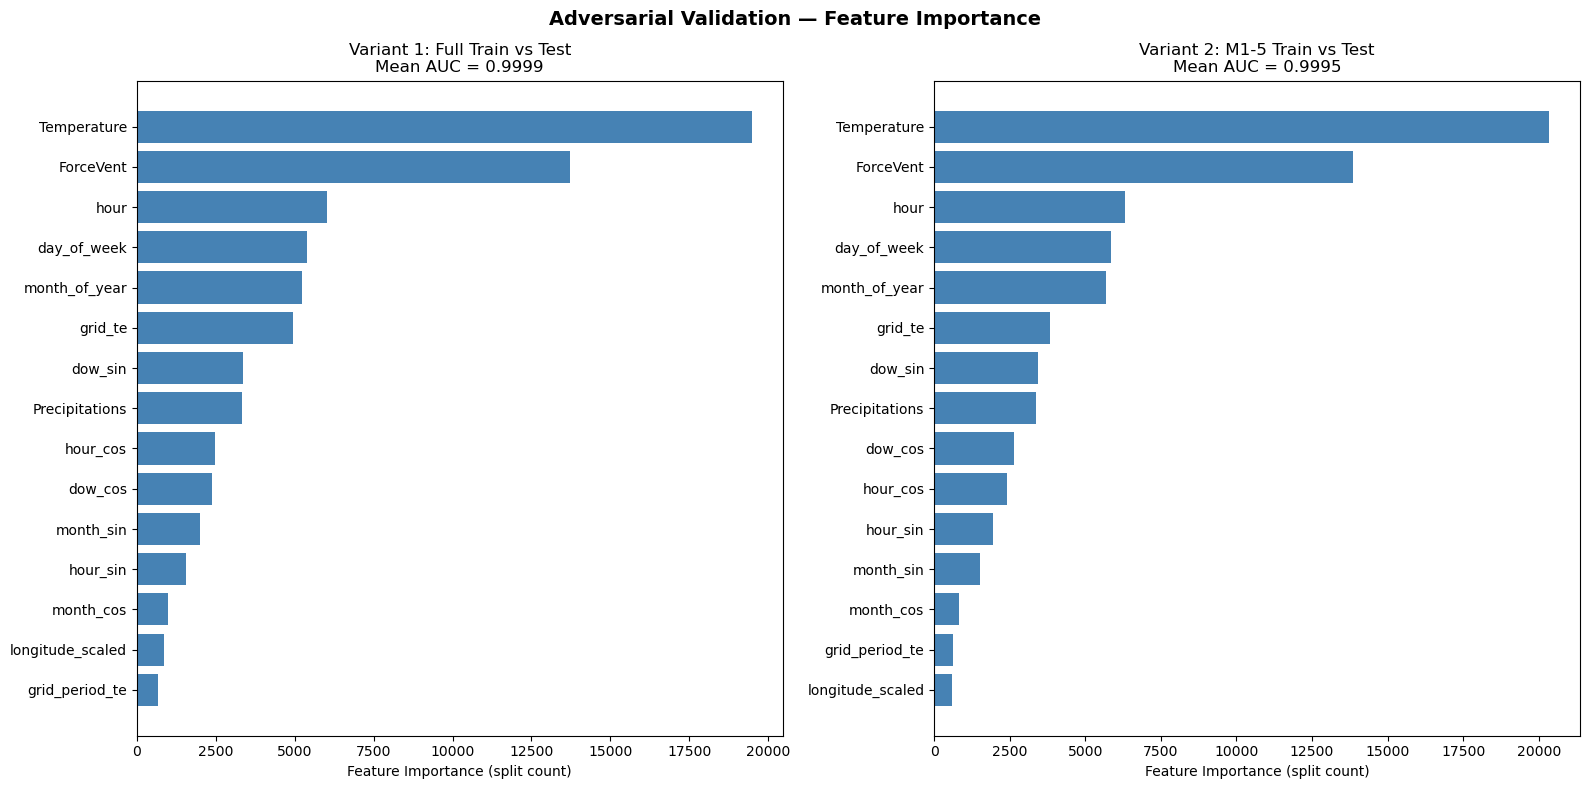

Saved: figures/av_feature_importance.png


In [12]:
# ── AV Feature Importance (both variants) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, imp, title, auc_val in [
    (axes[0], av1_importances, 'Variant 1: Full Train vs Test', av1_mean_auc),
    (axes[1], av2_importances, 'Variant 2: M1-5 Train vs Test', av2_mean_auc),
]:
    sorted_idx = np.argsort(imp)[::-1][:15]
    ax.barh(range(len(sorted_idx)), imp[sorted_idx][::-1], color='steelblue')
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([AV_FEATURES[i] for i in sorted_idx][::-1])
    ax.set_xlabel('Feature Importance (split count)')
    ax.set_title(f'{title}\nMean AUC = {auc_val:.4f}')

fig.suptitle('Adversarial Validation — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/av_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/av_feature_importance.png')

Computing AV probabilities for all train samples...
  AV probability stats for train samples:
    Mean: 0.1058
    Std:  0.1914
    Min:  0.0000  Max: 0.9951
    Median: 0.0100

  AV probability by month (mean):
    Month  1: 0.1857  (n=505,486)
    Month  2: 0.1874  (n=478,240)
    Month  3: 0.2041  (n=517,284)
    Month  4: 0.1121  (n=519,078)
    Month  5: 0.0024  (n=450,341)
    Month  6: 0.0022  (n=484,050)
    Month  7: 0.0018  (n=529,927)
    Month  8: 0.0175  (n=531,972)
    Month  9: 0.1093  (n=514,097)
    Month 10: 0.0513  (n=538,948)
    Month 11: 0.1975  (n=437,770)
    Month 12: 0.1985  (n=569,353)


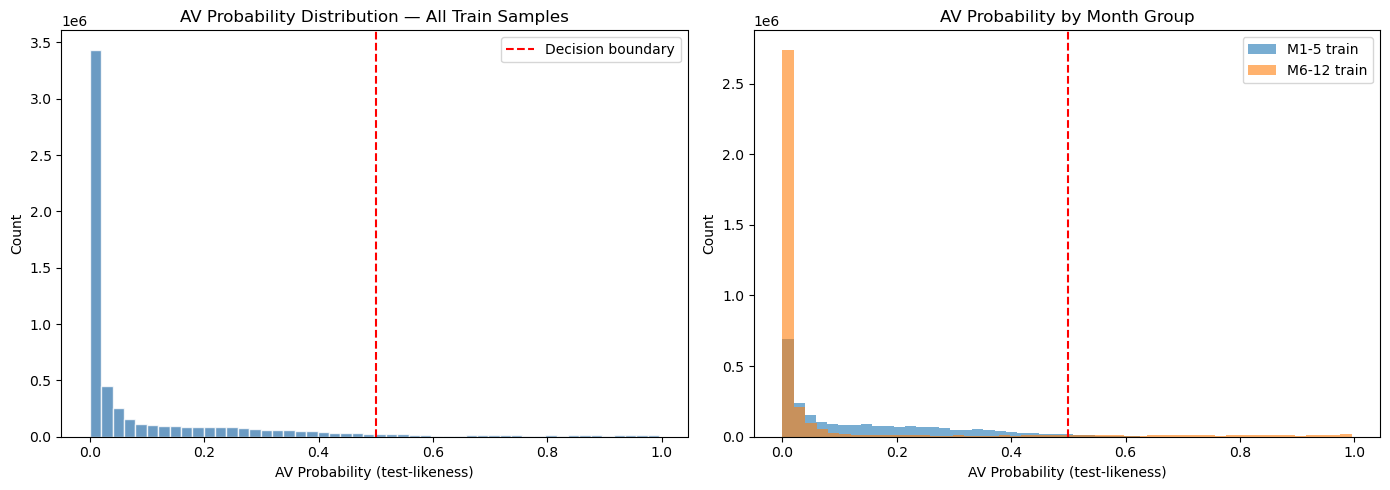

Saved: figures/av_probability_distribution.png


In [13]:
# ── Compute AV probabilities for ALL train samples (for sample weighting) ────
# Use M1-5 variant (Variant 2) — more relevant since test is M1-5 only.
# Re-train on full combined data with 5-fold to get OOF probs for train samples.

# For the FULL training set: train a final AV model on the combined M1-5 data
# and predict probability for every train row
print('Computing AV probabilities for all train samples...')

# Train final AV model on the M1-5 combined data
av_final = lgb.LGBMClassifier(**av_params)
av_final.fit(X_av2, y_av2)

# Predict "test-likeness" for ALL train rows
av_probs_train = av_final.predict_proba(train_df[AV_FEATURES])[:, 1]

print(f'  AV probability stats for train samples:')
print(f'    Mean: {av_probs_train.mean():.4f}')
print(f'    Std:  {av_probs_train.std():.4f}')
print(f'    Min:  {av_probs_train.min():.4f}  Max: {av_probs_train.max():.4f}')
print(f'    Median: {np.median(av_probs_train):.4f}')

# Distribution by month
print(f'\n  AV probability by month (mean):')
for m in range(1, 13):
    mask = train_df['month_of_year'].values == m
    if mask.sum() > 0:
        print(f'    Month {m:2d}: {av_probs_train[mask].mean():.4f}  (n={mask.sum():,})')

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(av_probs_train, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', ls='--', label='Decision boundary')
axes[0].set_xlabel('AV Probability (test-likeness)')
axes[0].set_ylabel('Count')
axes[0].set_title('AV Probability Distribution — All Train Samples')
axes[0].legend()

# By M1-5 vs M6-12
axes[1].hist(av_probs_train[m15_mask], bins=50, alpha=0.6, label='M1-5 train', color='tab:blue')
axes[1].hist(av_probs_train[~m15_mask], bins=50, alpha=0.6, label='M6-12 train', color='tab:orange')
axes[1].axvline(0.5, color='red', ls='--')
axes[1].set_xlabel('AV Probability (test-likeness)')
axes[1].set_ylabel('Count')
axes[1].set_title('AV Probability by Month Group')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/av_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/av_probability_distribution.png')

### Part 2 — Temporal CV (Diagnostic)

Train LGB + XGB on months 1-4 (using v7 params), validate on month 5.
This simulates the actual test scenario more closely than random 5-fold CV.

Compare:
- **Random 5-fold OOF**: v7 baseline (0.6429 ensemble, 0.6515 M1-5)
- **Temporal CV**: train M1-4, predict M5 → expected to be lower, quantifies the "temporal gap"

In [15]:
# ── Part 2: Temporal CV — Train M1-4, Validate M5 ────────────────────────────
import xgboost as xgb_lib
import time

EXCLUDE_COLS = ['invalid_ratio', 'grid_lon', 'grid_lat', 'grid_id', 'grid_period']
FEATURES = [c for c in train_df.columns if c not in EXCLUDE_COLS]

# Split by month
m14_mask = train_df['month_of_year'].isin([1,2,3,4]).values
m5_mask  = train_df['month_of_year'].values == 5

X_train_temporal = train_df.loc[m14_mask, FEATURES]
y_train_temporal = y[m14_mask]
X_val_temporal   = train_df.loc[m5_mask, FEATURES]
y_val_temporal   = y[m5_mask]

# Sample weights (log1p of total_count, same as v7)
w_train_temporal = np.log1p(train_df.loc[m14_mask, 'total_count'].values)

print(f'Temporal CV split:')
print(f'  Train (M1-4): {X_train_temporal.shape[0]:,} rows')
print(f'  Valid (M5):    {X_val_temporal.shape[0]:,} rows')
print(f'  Train fraction: {X_train_temporal.shape[0] / len(train_df):.1%}')

# ── LGB Temporal ─────────────────────────────────────────────────────────────
lgb_params_temporal = {
    'num_leaves':        100,
    'learning_rate':     0.0564,
    'min_child_samples': 69,
    'reg_lambda':        0.452,
    'reg_alpha':         1.243,
    'feature_fraction':  0.844,
    'bagging_fraction':  0.972,
    'objective':         'regression',
    'metric':            'l2',
    'boosting_type':     'gbdt',
    'bagging_freq':      5,
    'verbose':           -1,
    'n_jobs':            -1,
    'random_state':      SEED,
    'n_estimators':      10000,
}

print(f'\nTraining LGB (temporal: M1-4 → M5)...')
t0 = time.time()
lgb_temporal = lgb.LGBMRegressor(**lgb_params_temporal)
lgb_temporal.fit(
    X_train_temporal, y_train_temporal,
    eval_set=[(X_val_temporal, y_val_temporal)],
    sample_weight=w_train_temporal,
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=False),
        lgb.log_evaluation(period=2000),
    ]
)
lgb_temporal_pred = lgb_temporal.predict(X_val_temporal)
lgb_temporal_rho  = spearmanr(y_val_temporal, lgb_temporal_pred)[0]
lgb_temporal_time = time.time() - t0
print(f'  LGB Temporal: Spearman = {lgb_temporal_rho:.4f}  (best_iter={lgb_temporal.best_iteration_})  [{lgb_temporal_time:.0f}s]')

# ── XGB Temporal ─────────────────────────────────────────────────────────────
xgb_params_temporal = {
    'max_depth':         10,
    'learning_rate':     0.0362,
    'min_child_weight':  11,
    'reg_lambda':        1.561,
    'reg_alpha':         1.239,
    'colsample_bytree':  0.951,
    'subsample':         0.948,
    'objective':         'reg:squarederror',
    'eval_metric':       'rmse',
    'tree_method':       'hist',
    'n_estimators':      10000,
    'verbosity':         0,
    'random_state':      SEED,
    'n_jobs':            -1,
    'early_stopping_rounds': 150,
}

print(f'\nTraining XGB (temporal: M1-4 → M5)...')
t0 = time.time()
xgb_temporal = xgb_lib.XGBRegressor(**xgb_params_temporal)
xgb_temporal.fit(
    X_train_temporal, y_train_temporal,
    eval_set=[(X_val_temporal, y_val_temporal)],
    sample_weight=w_train_temporal,
    verbose=2000,
)
xgb_temporal_pred = xgb_temporal.predict(X_val_temporal)
xgb_temporal_rho  = spearmanr(y_val_temporal, xgb_temporal_pred)[0]
xgb_temporal_time = time.time() - t0
print(f'  XGB Temporal: Spearman = {xgb_temporal_rho:.4f}  (best_iter={xgb_temporal.best_iteration})  [{xgb_temporal_time:.0f}s]')

# ── Temporal Ensemble ────────────────────────────────────────────────────────
# Search optimal weights for temporal predictions
best_temporal_rho = -1
best_temporal_w   = None
for lgb_w in np.arange(0, 1.01, 0.05):
    xgb_w = 1.0 - lgb_w
    pred = lgb_w * lgb_temporal_pred + xgb_w * xgb_temporal_pred
    rho = spearmanr(y_val_temporal, pred)[0]
    if rho > best_temporal_rho:
        best_temporal_rho = rho
        best_temporal_w = (lgb_w, xgb_w)

print(f'\n  Temporal Ensemble: Spearman = {best_temporal_rho:.4f}  weights=LGB={best_temporal_w[0]:.2f}, XGB={best_temporal_w[1]:.2f}')

print(f'\n=== Temporal CV vs Random CV Comparison ===')
print(f'  {"Metric":<30} {"Random 5-Fold (v7)":<20} {"Temporal (M1-4→M5)":<20} {"Delta":<10}')
print(f'  {"-"*80}')
print(f'  {"LGB Spearman":<30} {"0.6336":<20} {lgb_temporal_rho:<20.4f} {lgb_temporal_rho - 0.6336:<+10.4f}')
print(f'  {"XGB Spearman":<30} {"0.6403":<20} {xgb_temporal_rho:<20.4f} {xgb_temporal_rho - 0.6403:<+10.4f}')
print(f'  {"Ensemble Spearman":<30} {"0.6429":<20} {best_temporal_rho:<20.4f} {best_temporal_rho - 0.6429:<+10.4f}')
print(f'  {"v7 M1-5 OOF (ref)":<30} {"0.6515":<20} {"—":<20}')
print(f'  {"Platform (v7, ref)":<30} {"0.5636":<20} {"—":<20}')

Temporal CV split:
  Train (M1-4): 2,020,088 rows
  Valid (M5):    450,341 rows
  Train fraction: 33.2%

Training LGB (temporal: M1-4 → M5)...
[2000]	valid_0's l2: 0.0836861
[4000]	valid_0's l2: 0.0823174
  LGB Temporal: Spearman = 0.5972  (best_iter=5660)  [192s]

Training XGB (temporal: M1-4 → M5)...
[0]	validation_0-rmse:0.36144
[2000]	validation_0-rmse:0.28683
[2747]	validation_0-rmse:0.28661
  XGB Temporal: Spearman = 0.5970  (best_iter=2597)  [119s]

  Temporal Ensemble: Spearman = 0.6017  weights=LGB=0.50, XGB=0.50

=== Temporal CV vs Random CV Comparison ===
  Metric                         Random 5-Fold (v7)   Temporal (M1-4→M5)   Delta     
  --------------------------------------------------------------------------------
  LGB Spearman                   0.6336               0.5972               -0.0364   
  XGB Spearman                   0.6403               0.5970               -0.0433   
  Ensemble Spearman              0.6429               0.6017               -0.0412   


### Part 2b — Temporal CV with AV Weights

If adversarial validation found significant shift (AUC > 0.6), we test whether
using AV probabilities as additional sample weights improves temporal CV performance.

`final_weight = log1p(total_count) * av_probability`

This gives higher weight to training samples that "look like" test data.

In [16]:
# ── Part 2b: Temporal CV with AV-weighted samples ────────────────────────────
# Only run if AV found meaningful shift
av_actionable = max(av1_mean_auc, av2_mean_auc) > 0.55  # lower threshold for diagnostic
print(f'AV actionable (AUC > 0.55): {av_actionable}  (best AUC: {max(av1_mean_auc, av2_mean_auc):.4f})')

if av_actionable:
    # Combined weight: log1p(total_count) * av_probability
    av_combined_weight = np.log1p(train_df['total_count'].values) * av_probs_train
    w_train_av = av_combined_weight[m14_mask]

    print(f'\nAV-combined weight stats (M1-4 train):')
    print(f'  Original log1p weight: mean={w_train_temporal.mean():.3f}, std={w_train_temporal.std():.3f}')
    print(f'  AV-combined weight:    mean={w_train_av.mean():.3f}, std={w_train_av.std():.3f}')

    # ── LGB with AV weights ──────────────────────────────────────────────────
    print(f'\nTraining LGB (temporal + AV weights)...')
    t0 = time.time()
    lgb_av = lgb.LGBMRegressor(**lgb_params_temporal)
    lgb_av.fit(
        X_train_temporal, y_train_temporal,
        eval_set=[(X_val_temporal, y_val_temporal)],
        sample_weight=w_train_av,
        callbacks=[
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=2000),
        ]
    )
    lgb_av_pred = lgb_av.predict(X_val_temporal)
    lgb_av_rho  = spearmanr(y_val_temporal, lgb_av_pred)[0]
    print(f'  LGB + AV weights: Spearman = {lgb_av_rho:.4f}  (best_iter={lgb_av.best_iteration_})  [{time.time()-t0:.0f}s]')

    # ── XGB with AV weights ──────────────────────────────────────────────────
    print(f'\nTraining XGB (temporal + AV weights)...')
    t0 = time.time()
    xgb_av = xgb_lib.XGBRegressor(**xgb_params_temporal)
    xgb_av.fit(
        X_train_temporal, y_train_temporal,
        eval_set=[(X_val_temporal, y_val_temporal)],
        sample_weight=w_train_av,
        verbose=2000,
    )
    xgb_av_pred = xgb_av.predict(X_val_temporal)
    xgb_av_rho  = spearmanr(y_val_temporal, xgb_av_pred)[0]
    print(f'  XGB + AV weights: Spearman = {xgb_av_rho:.4f}  (best_iter={xgb_av.best_iteration})  [{time.time()-t0:.0f}s]')

    # ── AV Ensemble ──────────────────────────────────────────────────────────
    best_av_ens_rho = -1
    best_av_ens_w = None
    for lgb_w in np.arange(0, 1.01, 0.05):
        xgb_w = 1.0 - lgb_w
        pred = lgb_w * lgb_av_pred + xgb_w * xgb_av_pred
        rho = spearmanr(y_val_temporal, pred)[0]
        if rho > best_av_ens_rho:
            best_av_ens_rho = rho
            best_av_ens_w = (lgb_w, xgb_w)

    print(f'\n  AV Ensemble: Spearman = {best_av_ens_rho:.4f}  weights=LGB={best_av_ens_w[0]:.2f}, XGB={best_av_ens_w[1]:.2f}')

    print(f'\n=== AV Weights Effect (Temporal CV on M5) ===')
    print(f'  {"Model":<25} {"No AV weight":<15} {"+ AV weight":<15} {"Delta":<10}')
    print(f'  {"-"*65}')
    print(f'  {"LGB":<25} {lgb_temporal_rho:<15.4f} {lgb_av_rho:<15.4f} {lgb_av_rho - lgb_temporal_rho:<+10.4f}')
    print(f'  {"XGB":<25} {xgb_temporal_rho:<15.4f} {xgb_av_rho:<15.4f} {xgb_av_rho - xgb_temporal_rho:<+10.4f}')
    print(f'  {"Ensemble":<25} {best_temporal_rho:<15.4f} {best_av_ens_rho:<15.4f} {best_av_ens_rho - best_temporal_rho:<+10.4f}')

    av_weights_helpful = best_av_ens_rho > best_temporal_rho + 0.001
    print(f'\n  AV weights helpful (delta > +0.001): {av_weights_helpful}')
    if av_weights_helpful:
        print('  → Recommend using AV-weighted training for full 5-fold retrain')
        np.save(f'{MODEL_DIR}av_probs_train.npy', av_probs_train)
        print(f'  → Saved av_probs_train.npy for use in full retraining')
    else:
        print('  → AV weights did not improve temporal CV — skip for production')
else:
    print('AV shift too weak — skipping AV-weighted temporal CV.')
    lgb_av_rho = None
    xgb_av_rho = None
    best_av_ens_rho = None

AV actionable (AUC > 0.55): True  (best AUC: 0.9999)

AV-combined weight stats (M1-4 train):
  Original log1p weight: mean=1.780, std=0.929
  AV-combined weight:    mean=0.304, std=0.328

Training LGB (temporal + AV weights)...
[2000]	valid_0's l2: 0.0847692
[4000]	valid_0's l2: 0.0837149
[6000]	valid_0's l2: 0.0832975
  LGB + AV weights: Spearman = 0.5902  (best_iter=6856)  [259s]

Training XGB (temporal + AV weights)...
[0]	validation_0-rmse:0.36113
[2000]	validation_0-rmse:0.28941
[3260]	validation_0-rmse:0.28875
  XGB + AV weights: Spearman = 0.5896  (best_iter=3110)  [166s]

  AV Ensemble: Spearman = 0.5937  weights=LGB=0.50, XGB=0.50

=== AV Weights Effect (Temporal CV on M5) ===
  Model                     No AV weight    + AV weight     Delta     
  -----------------------------------------------------------------
  LGB                       0.5972          0.5902          -0.0070   
  XGB                       0.5970          0.5896          -0.0074   
  Ensemble              

In [17]:
# ── Section D Summary ─────────────────────────────────────────────────────────
print('=' * 70)
print('SECTION D SUMMARY — Adversarial Validation + Temporal CV')
print('=' * 70)

print(f'\n--- Part 1: Adversarial Validation ---')
print(f'  AUC (Full train vs test):   {av1_mean_auc:.4f}')
print(f'  AUC (M1-5 train vs test):   {av2_mean_auc:.4f}')
if av1_mean_auc > 0.6:
    print(f'  → Significant distribution shift detected')
elif av1_mean_auc > 0.55:
    print(f'  → Moderate distribution shift detected')
else:
    print(f'  → Train and test distributions are similar (AUC near 0.5)')

print(f'\n--- Part 2: Temporal CV (M1-4 → M5) ---')
print(f'  LGB Temporal Spearman:      {lgb_temporal_rho:.4f}  (v7 random CV: 0.6336, delta: {lgb_temporal_rho - 0.6336:+.4f})')
print(f'  XGB Temporal Spearman:      {xgb_temporal_rho:.4f}  (v7 random CV: 0.6403, delta: {xgb_temporal_rho - 0.6403:+.4f})')
print(f'  Ensemble Temporal Spearman: {best_temporal_rho:.4f}  (v7 random CV: 0.6429, delta: {best_temporal_rho - 0.6429:+.4f})')

if best_av_ens_rho is not None:
    print(f'\n--- Part 2b: AV-Weighted Temporal CV ---')
    print(f'  Ensemble + AV weights:      {best_av_ens_rho:.4f}  (vs no-AV: {best_temporal_rho:.4f}, delta: {best_av_ens_rho - best_temporal_rho:+.4f})')

print(f'\n--- Conclusions ---')
temporal_gap = 0.6429 - best_temporal_rho
print(f'  Temporal CV gap from random CV: {temporal_gap:.4f}')
print(f'  Platform gap (v7):              {0.6429 - 0.5636:.4f}')
if temporal_gap > 0.02:
    print(f'  → Temporal CV confirms significant temporal distribution shift')
    print(f'  → Temporal CV Spearman ({best_temporal_rho:.4f}) is a better proxy for platform score than random CV')
else:
    print(f'  → Temporal gap is small — random CV is a reasonable proxy')

if best_av_ens_rho is not None and best_av_ens_rho > best_temporal_rho + 0.001:
    print(f'  → AV weights IMPROVE temporal CV — recommend for full retraining')
else:
    print(f'  → AV weights did NOT improve temporal CV — not recommended for production')

print(f'\n--- Next Steps ---')
print(f'  Use Temporal CV as primary evaluation metric for subsequent experiments')
print(f'  Baseline to beat (Temporal Ensemble): {best_temporal_rho:.4f}')
print('=' * 70)

SECTION D SUMMARY — Adversarial Validation + Temporal CV

--- Part 1: Adversarial Validation ---
  AUC (Full train vs test):   0.9999
  AUC (M1-5 train vs test):   0.9995
  → Significant distribution shift detected

--- Part 2: Temporal CV (M1-4 → M5) ---
  LGB Temporal Spearman:      0.5972  (v7 random CV: 0.6336, delta: -0.0364)
  XGB Temporal Spearman:      0.5970  (v7 random CV: 0.6403, delta: -0.0433)
  Ensemble Temporal Spearman: 0.6017  (v7 random CV: 0.6429, delta: -0.0412)

--- Part 2b: AV-Weighted Temporal CV ---
  Ensemble + AV weights:      0.5937  (vs no-AV: 0.6017, delta: -0.0080)

--- Conclusions ---
  Temporal CV gap from random CV: 0.0412
  Platform gap (v7):              0.0793
  → Temporal CV confirms significant temporal distribution shift
  → Temporal CV Spearman (0.6017) is a better proxy for platform score than random CV
  → AV weights did NOT improve temporal CV — not recommended for production

--- Next Steps ---
  Use Temporal CV as primary evaluation metric f

---
## Section C — Rank-Based Target Training

**Rationale**: Models currently train on raw `invalid_ratio` (bimodal: many 0s and 1s
from total_count=1 noise). Since Spearman only cares about rank ordering, training on
`y_rank = rankdata(y) / N` (uniform [0,1]) makes MSE directly optimise ranking accuracy.

**Reference**: Paper 3 (Blondel 2020, Fast Differentiable Sorting)

**GPU training**: Run `python scripts/step_c_gpu.py` on the GPU server.
Then download the following files and place them in `models/`:
- `lgb_rank_oof.npy`, `lgb_rank_test.npy`
- `xgb_rank_oof.npy`, `xgb_rank_test.npy`
- (optional combined submission) `submissions/ensemble_c_combined.csv`

This section loads those results and does local analysis — no heavy computation needed.

**Success criteria**: Stage 1 OOF ≥ 0.635; combined ensemble OOF > 0.6429 (v7 baseline).

In [5]:
# ── Section C: self-contained setup ──────────────────────────────────────────
# Run this cell first if starting Section C without running prior sections.
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import os

SEED = 42
DATA_DIR   = '../data/'
MODEL_DIR  = '../models/'
SUBMIT_DIR = '../submissions/'
np.random.seed(SEED)

try:
    _ = train_df.shape
    y = train_df['invalid_ratio'].values   # re-derive to be safe
    print(f'Using session data — Train: {train_df.shape}  Test: {test_df.shape}')
except NameError:
    print('Loading data for Section C (standalone run)...')
    train_df = pd.read_parquet(f'{DATA_DIR}train_features_tier2.parquet')
    test_df  = pd.read_parquet(f'{DATA_DIR}test_features_tier2.parquet')
    y = train_df['invalid_ratio'].values
    print(f'  Train: {train_df.shape}  Test: {test_df.shape}')

m15_mask = train_df['month_of_year'].isin([1, 2, 3, 4, 5]).values
y_m15    = y[m15_mask]
print(f'M1-5 rows: {m15_mask.sum():,}  All rows: {len(y):,}')

Using session data — Train: (6076546, 31)  Test: (2028750, 30)
M1-5 rows: 2,470,429  All rows: 6,076,546


In [6]:
# ── Load GPU results ──────────────────────────────────────────────────────────
# Expected files (download from GPU server after running step_c_gpu.py):
#   models/lgb_rank_oof.npy  lgb_rank_test.npy
#   models/xgb_rank_oof.npy  xgb_rank_test.npy

def _load(name, shape_hint=None):
    path = f'{MODEL_DIR}{name}'
    if os.path.exists(path):
        arr = np.load(path)
        print(f'  Loaded {name}  shape={arr.shape}')
        return arr
    print(f'  MISSING: {name}  (run step_c_gpu.py on GPU server first)')
    return None

print('Loading rank-target OOF predictions...')
lgb_rank_oof  = _load('lgb_rank_oof.npy')
xgb_rank_oof  = _load('xgb_rank_oof.npy')

print('\nLoading rank-target test predictions...')
lgb_rank_test = _load('lgb_rank_test.npy')
xgb_rank_test = _load('xgb_rank_test.npy')

# v7 OOF proxy (v8a OOF ≡ v7 OOF — training was identical, only test-time TE differs)
print('\nLoading v7 OOF proxy (v8a)...')
lgb_v7_oof = _load('lgb_oof_v8a.npy')
if lgb_v7_oof is None:
    lgb_v7_oof = _load('lgb_oof_v7.npy')
xgb_v7_oof = _load('xgb_oof_v8a.npy')
if xgb_v7_oof is None:
    xgb_v7_oof = _load('xgb_oof_v7.npy')

# v7 test predictions (prefer v7 with full TE over v8a with M1-5 TE)
print('\nLoading v7 test predictions...')
lgb_v7_test = _load('lgb_test_v7.npy')
xgb_v7_test = _load('xgb_test_v7.npy')
if lgb_v7_test is None:
    lgb_v7_test = _load('lgb_test_v8a.npy')
    if lgb_v7_test is not None:
        print('    WARNING: using v8a test (M1-5 TE), which was proven harmful (+0.013 gap). '
              'Download lgb_test_v7.npy for best results.')
if xgb_v7_test is None:
    xgb_v7_test = _load('xgb_test_v8a.npy')

print('\nStatus summary:')
print(f'  rank LGB OOF:  {"✓" if lgb_rank_oof is not None else "✗ MISSING"}')
print(f'  rank XGB OOF:  {"✓" if xgb_rank_oof is not None else "✗ MISSING"}')
print(f'  rank LGB test: {"✓" if lgb_rank_test is not None else "✗ MISSING"}')
print(f'  rank XGB test: {"✓" if xgb_rank_test is not None else "✗ MISSING"}')
print(f'  v7 LGB OOF:    {"✓" if lgb_v7_oof is not None else "✗ MISSING (needed for 4-model ensemble)"}')
print(f'  v7 XGB OOF:    {"✓" if xgb_v7_oof is not None else "✗ MISSING"}')
print(f'  v7 LGB test:   {"✓" if lgb_v7_test is not None else "✗ MISSING (needed for combined submission)"}')
print(f'  v7 XGB test:   {"✓" if xgb_v7_test is not None else "✗ MISSING"}')

Loading rank-target OOF predictions...
  Loaded lgb_rank_oof.npy  shape=(6076546,)
  Loaded xgb_rank_oof.npy  shape=(6076546,)

Loading rank-target test predictions...
  Loaded lgb_rank_test.npy  shape=(2028750,)
  Loaded xgb_rank_test.npy  shape=(2028750,)

Loading v7 OOF proxy (v8a)...
  Loaded lgb_oof_v8a.npy  shape=(6076546,)
  Loaded xgb_oof_v8a.npy  shape=(6076546,)

Loading v7 test predictions...
  Loaded lgb_test_v7.npy  shape=(2028750,)
  Loaded xgb_test_v7.npy  shape=(2028750,)

Status summary:
  rank LGB OOF:  ✓
  rank XGB OOF:  ✓
  rank LGB test: ✓
  rank XGB test: ✓
  v7 LGB OOF:    ✓
  v7 XGB OOF:    ✓
  v7 LGB test:   ✓
  v7 XGB test:   ✓


In [7]:
# ── Stage 1: Evaluate rank-target model performance ───────────────────────────
assert lgb_rank_oof is not None and xgb_rank_oof is not None, \
    "Run step_c_gpu.py first and download the OOF files."

lgb_rho  = spearmanr(y, lgb_rank_oof)[0]
xgb_rho  = spearmanr(y, xgb_rank_oof)[0]
lgb_m15  = spearmanr(y_m15, lgb_rank_oof[m15_mask])[0]
xgb_m15  = spearmanr(y_m15, xgb_rank_oof[m15_mask])[0]

print('=== Stage 1: Rank-Target GBDT Results ===\n')
print(f'  {"Model":<25} {"OOF":>8} {"M1-5 OOF":>10} {"vs v7":>8}')
print(f'  {"-"*55}')
print(f'  {"LGB (rank target)":<25} {lgb_rho:>8.4f} {lgb_m15:>10.4f} {lgb_rho-0.6336:>+8.4f}')
print(f'  {"XGB (rank target)":<25} {xgb_rho:>8.4f} {xgb_m15:>10.4f} {xgb_rho-0.6403:>+8.4f}')
print(f'  {"v7 LGB (baseline)":<25} {"0.6336":>8} {"0.6428":>10} {"—":>8}')
print(f'  {"v7 XGB (baseline)":<25} {"0.6403":>8} {"0.6482":>10} {"—":>8}')

print(f'\n  Success criteria:')
print(f'  Stage 1 OOF >= 0.635: '
      f'{"✓ PASS" if max(lgb_rho, xgb_rho) >= 0.635 else "✗ FAIL"}  '
      f'(best: {max(lgb_rho, xgb_rho):.4f})')

# Inter-model correlations
corr_rank = spearmanr(lgb_rank_oof, xgb_rank_oof)[0]
print(f'\n  rank LGB — rank XGB correlation: {corr_rank:.4f}')

if lgb_v7_oof is not None:
    c_lv_lr = spearmanr(lgb_v7_oof, lgb_rank_oof)[0]
    c_xv_xr = spearmanr(xgb_v7_oof, xgb_rank_oof)[0]
    c_lv_xv = spearmanr(lgb_v7_oof, xgb_v7_oof)[0]
    print(f'  v7 LGB — rank LGB:     {c_lv_lr:.4f}')
    print(f'  v7 XGB — rank XGB:     {c_xv_xr:.4f}')
    print(f'  v7 LGB — v7 XGB (ref): {c_lv_xv:.4f}')
    if c_lv_lr < 0.97:
        print('\n  rank models provide DIVERSE signal vs v7 (< 0.97) — worth stacking')
    else:
        print('\n  rank models are HIGHLY correlated with v7 (>= 0.97) — stacking unlikely to help')

=== Stage 1: Rank-Target GBDT Results ===

  Model                          OOF   M1-5 OOF    vs v7
  -------------------------------------------------------
  LGB (rank target)           0.6373     0.6440  +0.0037
  XGB (rank target)           0.6430     0.6486  +0.0027
  v7 LGB (baseline)           0.6336     0.6428        —
  v7 XGB (baseline)           0.6403     0.6482        —

  Success criteria:
  Stage 1 OOF >= 0.635: ✓ PASS  (best: 0.6430)

  rank LGB — rank XGB correlation: 0.9628
  v7 LGB — rank LGB:     0.9899
  v7 XGB — rank XGB:     0.9915
  v7 LGB — v7 XGB (ref): 0.9650

  rank models are HIGHLY correlated with v7 (>= 0.97) — stacking unlikely to help


In [8]:
# ── Ensemble weight search ────────────────────────────────────────────────────
# Ensemble A: rank-target only (LGB + XGB)
print('=== Ensemble A: Rank-Target Only (LGB + XGB) ===\n')
best_a_rho, best_a_lgb_w = -1, 0.5
for lgb_w in np.arange(0.0, 1.01, 0.01):
    xgb_w = 1.0 - lgb_w
    rho   = spearmanr(y, lgb_w * lgb_rank_oof + xgb_w * xgb_rank_oof)[0]
    if rho > best_a_rho:
        best_a_rho, best_a_lgb_w = rho, lgb_w
best_a_xgb_w = 1.0 - best_a_lgb_w
ens_a_oof    = best_a_lgb_w * lgb_rank_oof + best_a_xgb_w * xgb_rank_oof
ens_a_m15    = spearmanr(y_m15, ens_a_oof[m15_mask])[0]

print(f'  Best weights: LGB={best_a_lgb_w:.2f}  XGB={best_a_xgb_w:.2f}')
print(f'  OOF Spearman:  {best_a_rho:.4f}  (v7: 0.6429, delta: {best_a_rho-0.6429:+.4f})')
print(f'  M1-5 Spearman: {ens_a_m15:.4f}  (v7: 0.6515, delta: {ens_a_m15-0.6515:+.4f})')

# Ensemble B: combined v7 + rank-target (4 models) — only if v7 OOF available
if lgb_v7_oof is not None:
    print(f'\n=== Ensemble B: Combined v7 + Rank-Target (4 models) ===\n')
    best_b_rho = -1
    best_b_w   = (0.175, 0.325, 0.175, 0.325)
    ws = np.arange(0.0, 1.01, 0.05)
    for w1 in ws:           # v7 LGB
        for w2 in ws:       # v7 XGB
            for w3 in ws:   # rank LGB
                w4 = round(1.0 - w1 - w2 - w3, 4)
                if w4 < 0 or w4 > 1:
                    continue
                pred = (w1 * lgb_v7_oof + w2 * xgb_v7_oof
                      + w3 * lgb_rank_oof + w4 * xgb_rank_oof)
                rho  = spearmanr(y, pred)[0]
                if rho > best_b_rho:
                    best_b_rho = rho
                    best_b_w   = (w1, w2, w3, w4)
    w1, w2, w3, w4 = best_b_w
    ens_b_oof = (w1 * lgb_v7_oof + w2 * xgb_v7_oof
               + w3 * lgb_rank_oof + w4 * xgb_rank_oof)
    ens_b_m15 = spearmanr(y_m15, ens_b_oof[m15_mask])[0]

    print(f'  Best weights: v7LGB={w1:.2f}  v7XGB={w2:.2f}  rankLGB={w3:.2f}  rankXGB={w4:.2f}')
    print(f'  OOF Spearman:  {best_b_rho:.4f}  (v7: 0.6429, delta: {best_b_rho-0.6429:+.4f})')
    print(f'  M1-5 Spearman: {ens_b_m15:.4f}  (v7: 0.6515, delta: {ens_b_m15-0.6515:+.4f})')
    if w3 == 0 and w4 == 0:
        print('\n  WARNING: rank models got zero weight — rank target adds no value over v7')
    elif best_b_rho > 0.6429 + 0.001:
        print(f'\n  Combined ensemble BEATS v7 by {best_b_rho-0.6429:+.4f} — submit!')
    else:
        print(f'\n  Combined ensemble does not substantially exceed v7')
else:
    print('\n  Ensemble B skipped (v7 OOF not available)')

=== Ensemble A: Rank-Target Only (LGB + XGB) ===

  Best weights: LGB=0.39  XGB=0.61
  OOF Spearman:  0.6464  (v7: 0.6429, delta: +0.0035)
  M1-5 Spearman: 0.6527  (v7: 0.6515, delta: +0.0012)

=== Ensemble B: Combined v7 + Rank-Target (4 models) ===

  Best weights: v7LGB=0.00  v7XGB=0.05  rankLGB=0.40  rankXGB=0.55
  OOF Spearman:  0.6465  (v7: 0.6429, delta: +0.0036)
  M1-5 Spearman: 0.6529  (v7: 0.6515, delta: +0.0014)

  Combined ensemble BEATS v7 by +0.0036 — submit!


In [9]:
# ── Generate submission files ─────────────────────────────────────────────────
assert lgb_rank_test is not None and xgb_rank_test is not None, \
    "Test predictions missing. Download lgb_rank_test.npy and xgb_rank_test.npy."

submissions_created = []

# Submission 1: rank-target only ensemble
ens_a_test = best_a_lgb_w * lgb_rank_test + best_a_xgb_w * xgb_rank_test
ens_a_test = np.clip(ens_a_test, 0, 1)
assert len(ens_a_test) == len(test_df), f'Shape mismatch: {len(ens_a_test)} vs {len(test_df)}'
assert not np.isnan(ens_a_test).any(), 'NaN in predictions!'

out_a = f'{SUBMIT_DIR}ensemble_c_rank.csv'
pd.DataFrame({'id': test_df.index, 'invalid_ratio': ens_a_test}).to_csv(out_a, index=False)
print(f'Saved: {out_a}')
print(f'  Rows: {len(ens_a_test):,}  Range: [{ens_a_test.min():.4f}, {ens_a_test.max():.4f}]')
print(f'  OOF: {best_a_rho:.4f}  (rank-only ensemble)')
submissions_created.append(('ensemble_c_rank.csv', best_a_rho, 'rank-target only'))

# Submission 2: combined v7 + rank-target (4-model)
if lgb_v7_oof is not None and lgb_v7_test is not None and xgb_v7_test is not None:
    w1, w2, w3, w4 = best_b_w
    ens_b_test = (w1 * lgb_v7_test + w2 * xgb_v7_test
                + w3 * lgb_rank_test + w4 * xgb_rank_test)
    ens_b_test = np.clip(ens_b_test, 0, 1)
    assert len(ens_b_test) == len(test_df)
    assert not np.isnan(ens_b_test).any()

    out_b = f'{SUBMIT_DIR}ensemble_c_combined.csv'
    pd.DataFrame({'id': test_df.index, 'invalid_ratio': ens_b_test}).to_csv(out_b, index=False)
    print(f'\nSaved: {out_b}')
    print(f'  Rows: {len(ens_b_test):,}  Range: [{ens_b_test.min():.4f}, {ens_b_test.max():.4f}]')
    print(f'  OOF: {best_b_rho:.4f}  (v7 + rank 4-model ensemble)')
    submissions_created.append(('ensemble_c_combined.csv', best_b_rho, 'v7+rank 4-model'))
else:
    print('\nCombined submission skipped (v7 test predictions not locally available).')
    print('If GPU server produced ensemble_c_combined.csv, use that directly.')

print(f'\n=== Submission Plan ===')
for fname, oof, label in sorted(submissions_created, key=lambda x: -x[1]):
    print(f'  {fname:<35} OOF={oof:.4f}  ({label})')
print(f'  v7 baseline (ensemble_v7.csv)       OOF=0.6429  Platform=0.5636')
print('\nRecommendation: submit the file with the highest OOF first.')

Saved: ../submissions/ensemble_c_rank.csv
  Rows: 2,028,750  Range: [0.0205, 1.0000]
  OOF: 0.6464  (rank-only ensemble)

Saved: ../submissions/ensemble_c_combined.csv
  Rows: 2,028,750  Range: [0.0163, 1.0000]
  OOF: 0.6465  (v7 + rank 4-model ensemble)

=== Submission Plan ===
  ensemble_c_combined.csv             OOF=0.6465  (v7+rank 4-model)
  ensemble_c_rank.csv                 OOF=0.6464  (rank-target only)
  v7 baseline (ensemble_v7.csv)       OOF=0.6429  Platform=0.5636

Recommendation: submit the file with the highest OOF first.


In [10]:
# ── Section C Summary ─────────────────────────────────────────────────────────
print('=' * 70)
print('SECTION C SUMMARY — Rank-Based Target Training')
print('=' * 70)

print(f'\n--- Stage 1: Rank-Target GBDT ---')
print(f'  LGB rank target OOF:  {lgb_rho:.4f}  (v7 LGB: 0.6336, delta: {lgb_rho-0.6336:+.4f})')
print(f'  XGB rank target OOF:  {xgb_rho:.4f}  (v7 XGB: 0.6403, delta: {xgb_rho-0.6403:+.4f})')
print(f'  Stage 1 pass (>= 0.635): '
      f'{"✓ PASS" if max(lgb_rho, xgb_rho) >= 0.635 else "✗ FAIL"}')

print(f'\n--- Ensemble Results ---')
print(f'  Rank-only ensemble OOF:   {best_a_rho:.4f}  '
      f'(delta vs v7: {best_a_rho-0.6429:+.4f})')
if lgb_v7_oof is not None:
    print(f'  Combined 4-model OOF:     {best_b_rho:.4f}  '
          f'(delta vs v7: {best_b_rho-0.6429:+.4f})')

print(f'\n--- Conclusions ---')
if max(lgb_rho, xgb_rho) >= 0.635:
    print(f'  Rank target training MEETS Stage 1 criterion.')
    if lgb_v7_oof is not None and best_b_rho > 0.6429 + 0.001:
        print(f'  Combined ensemble IMPROVES on v7 by {best_b_rho-0.6429:+.4f} — submit ensemble_c_combined.csv')
    elif best_a_rho > 0.6429 + 0.001:
        print(f'  Rank-only ensemble improves on v7 — submit ensemble_c_rank.csv')
    else:
        print(f'  However, rank target does not improve ensemble over v7.')
        print(f'  Rank models likely carry redundant signal (check correlation above).')
else:
    print(f'  Rank target training DOES NOT meet Stage 1 criterion (OOF < 0.635).')
    print(f'  Rank transformation may not benefit this dataset.')
    print(f'  Skip Stage 2 (torchsort) — insufficient base model quality.')

print(f'\n--- Stage 2 (torchsort, optional) ---')
if max(lgb_rho, xgb_rho) >= 0.635:
    print(f'  Stage 1 passed → Stage 2 is viable if more improvement needed.')
    print(f'  torchsort differentiable Spearman post-processing can refine rankings')
    print(f'  but requires ~2h additional GPU time. Skip if report deadline is near.')
else:
    print(f'  Stage 1 failed → skip Stage 2.')
print('=' * 70)

SECTION C SUMMARY — Rank-Based Target Training

--- Stage 1: Rank-Target GBDT ---
  LGB rank target OOF:  0.6373  (v7 LGB: 0.6336, delta: +0.0037)
  XGB rank target OOF:  0.6430  (v7 XGB: 0.6403, delta: +0.0027)
  Stage 1 pass (>= 0.635): ✓ PASS

--- Ensemble Results ---
  Rank-only ensemble OOF:   0.6464  (delta vs v7: +0.0035)
  Combined 4-model OOF:     0.6465  (delta vs v7: +0.0036)

--- Conclusions ---
  Rank target training MEETS Stage 1 criterion.
  Combined ensemble IMPROVES on v7 by +0.0036 — submit ensemble_c_combined.csv

--- Stage 2 (torchsort, optional) ---
  Stage 1 passed → Stage 2 is viable if more improvement needed.
  torchsort differentiable Spearman post-processing can refine rankings
  but requires ~2h additional GPU time. Skip if report deadline is near.


---
## Section H — GBDT Label Noise Handling

**Rationale**: 25% of training samples have `total_count=1`, making `invalid_ratio`
binary noise (exactly 0 or 1).  v7 already reduces their influence via `log1p(total_count)`
weighting (weight 0.693 vs 2.40 for tc=10), but the labels themselves remain noisy.

We use the v7 ensemble OOF predictions to identify "confidently wrong" tc=1 samples
and test three handling strategies:

| Strategy | Description |
|----------|-------------|
| (a) Remove | Drop noise candidates from training entirely |
| (b) Down-weight | Set sample_weight = 0.1 (vs 0.693 baseline) |
| (c) Label smooth | y=1 noise → 0.8,  y=0 noise → 0.2 |

**Noise criteria** (applied to `total_count=1` samples only):
- `pred < 0.15` but `y = 1` → model confidently predicts low, label says high (noisy)
- `pred > 0.85` but `y = 0` → model confidently predicts high, label says low (noisy)

**GPU training**: Run `python scripts/step_h_gpu.py` on the GPU server (~3h total).
Download the output `.npy` files to `models/` before running the evaluation cells.

**Success criterion**: Ensemble OOF ≥ 0.6424 (matching v7 within −0.0005)

**Reference**: Paper 5 (GBDT Label Noise 2024)

In [11]:
# ── Section H: self-contained setup ──────────────────────────────────────────
# Run this cell first if starting Section H without running prior sections.
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import os

SEED = 42
DATA_DIR   = '../data/'
MODEL_DIR  = '../models/'
SUBMIT_DIR = '../submissions/'
np.random.seed(SEED)

# Reuse session variables if already loaded (avoids re-reading 600 MB parquet)
try:
    _ = train_df.shape
    y_h       = train_df['invalid_ratio'].values.astype(np.float32)
    tc_h      = train_df['total_count'].values
    m15_h     = train_df['month_of_year'].isin([1, 2, 3, 4, 5]).values
    print(f'Reusing session train_df  shape={train_df.shape}')
except NameError:
    print('Loading data from disk...')
    train_df = pd.read_parquet(f'{DATA_DIR}train_features_tier2.parquet')
    test_df  = pd.read_parquet(f'{DATA_DIR}test_features_tier2.parquet')
    y_h       = train_df['invalid_ratio'].values.astype(np.float32)
    tc_h      = train_df['total_count'].values
    m15_h     = train_df['month_of_year'].isin([1, 2, 3, 4, 5]).values
    print(f'Loaded train_df {train_df.shape},  test_df {test_df.shape}')

# Load v7 OOF + test (used for noise identification and ensemble baseline)
lgb_oof_v7_h  = np.load(f'{MODEL_DIR}lgb_oof_v7.npy')
xgb_oof_v7_h  = np.load(f'{MODEL_DIR}xgb_oof_v7.npy')
lgb_test_v7_h = np.load(f'{MODEL_DIR}lgb_test_v7.npy')
xgb_test_v7_h = np.load(f'{MODEL_DIR}xgb_test_v7.npy')

# v7 ensemble OOF (established weights)
ens_oof_v7_h = 0.35 * lgb_oof_v7_h + 0.65 * xgb_oof_v7_h

print(f'\nv7 LGB OOF:           {spearmanr(y_h, lgb_oof_v7_h)[0]:.4f}')
print(f'v7 XGB OOF:           {spearmanr(y_h, xgb_oof_v7_h)[0]:.4f}')
print(f'v7 Ensemble OOF:      {spearmanr(y_h, ens_oof_v7_h)[0]:.4f}')
print(f'v7 Ensemble M1-5 OOF: {spearmanr(y_h[m15_h], ens_oof_v7_h[m15_h])[0]:.4f}')


Reusing session train_df  shape=(6076546, 31)

v7 LGB OOF:           0.6336
v7 XGB OOF:           0.6403
v7 Ensemble OOF:      0.6429
v7 Ensemble M1-5 OOF: 0.6515


=== tc=1 Subset Analysis ===

  Total training samples:           6,076,546
  total_count=1 samples:            1,532,442  (25.2%)
  tc=1 with y=0:                      517,821  (8.5%)
  tc=1 with y=1:                    1,014,621  (16.7%)

  Noise: pred<0.15 & y=1 (tc=1):       2,168  (0.04% of train)
  Noise: pred>0.85 & y=0 (tc=1):      34,340  (0.57% of train)
  Total noise candidates:              36,508  (0.60% of train)

  Spearman  all tc=1:              0.4521
  Spearman  clean tc=1 (non-noise): 0.5230
  Spearman  tc>=2:                 0.7243


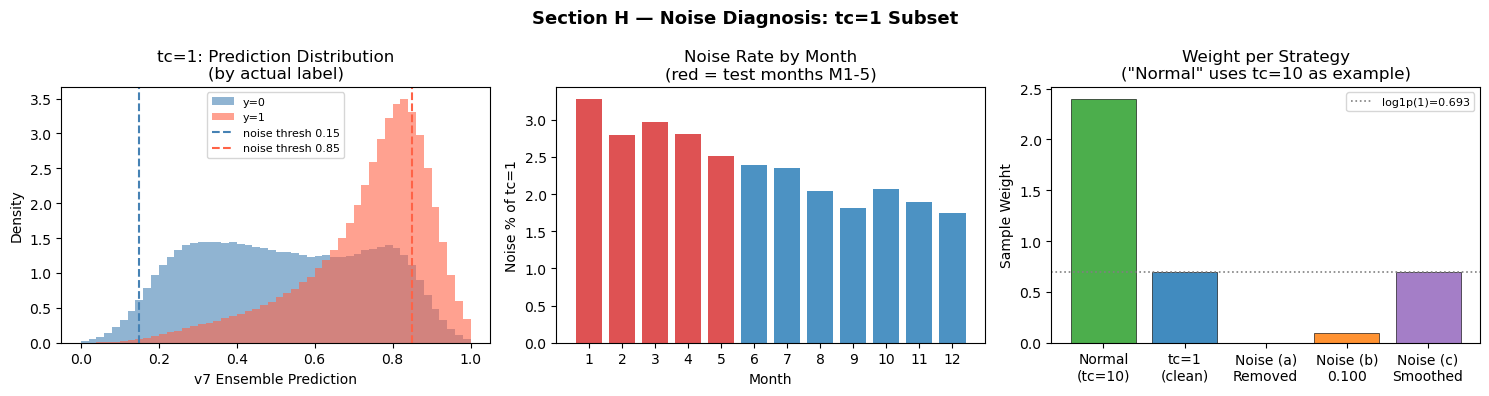

Figure saved to docs/figures/fig_h_noise_diagnosis.png


In [12]:
# ── Section H: Noise Diagnosis ───────────────────────────────────────────────
# Identify noise candidates using v7 OOF predictions on the tc=1 subset.

NOISE_LOW  = 0.15   # pred < threshold but y=1  → noisy (predicted low, label high)
NOISE_HIGH = 0.85   # pred > threshold but y=0  → noisy (predicted high, label low)

tc1_h   = (tc_h == 1)
nlo_h   = tc1_h & (ens_oof_v7_h < NOISE_LOW)  & (y_h == 1)   # low-pred noise
nhi_h   = tc1_h & (ens_oof_v7_h > NOISE_HIGH) & (y_h == 0)   # high-pred noise
noise_h = nlo_h | nhi_h

print('=== tc=1 Subset Analysis ===\n')
print(f'  Total training samples:          {len(y_h):>10,}')
print(f'  total_count=1 samples:           {tc1_h.sum():>10,}  ({tc1_h.mean()*100:.1f}%)')
print(f'  tc=1 with y=0:                   '
      f'{(tc1_h & (y_h==0)).sum():>10,}  ({(tc1_h & (y_h==0)).mean()*100:.1f}%)')
print(f'  tc=1 with y=1:                   '
      f'{(tc1_h & (y_h==1)).sum():>10,}  ({(tc1_h & (y_h==1)).mean()*100:.1f}%)')
print()
print(f'  Noise: pred<{NOISE_LOW} & y=1 (tc=1):  {nlo_h.sum():>10,}  '
      f'({nlo_h.mean()*100:.2f}% of train)')
print(f'  Noise: pred>{NOISE_HIGH} & y=0 (tc=1):  {nhi_h.sum():>10,}  '
      f'({nhi_h.mean()*100:.2f}% of train)')
print(f'  Total noise candidates:          {noise_h.sum():>10,}  '
      f'({noise_h.mean()*100:.2f}% of train)')
print()

# Spearman on subgroups
clean_tc1 = tc1_h & ~noise_h
print(f'  Spearman  all tc=1:              '
      f'{spearmanr(y_h[tc1_h], ens_oof_v7_h[tc1_h])[0]:.4f}')
print(f'  Spearman  clean tc=1 (non-noise):'
      f' {spearmanr(y_h[clean_tc1], ens_oof_v7_h[clean_tc1])[0]:.4f}')
print(f'  Spearman  tc>=2:                 '
      f'{spearmanr(y_h[tc_h>=2], ens_oof_v7_h[tc_h>=2])[0]:.4f}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Section H — Noise Diagnosis: tc=1 Subset', fontsize=13, fontweight='bold')

# Panel 1: prediction distribution for tc=1 by label
ax = axes[0]
bins = np.linspace(0, 1, 51)
ax.hist(ens_oof_v7_h[tc1_h & (y_h == 0)], bins=bins, alpha=0.6,
        color='steelblue', label='y=0', density=True)
ax.hist(ens_oof_v7_h[tc1_h & (y_h == 1)], bins=bins, alpha=0.6,
        color='tomato', label='y=1', density=True)
ax.axvline(NOISE_LOW,  color='steelblue', ls='--', lw=1.5,
           label=f'noise thresh {NOISE_LOW}')
ax.axvline(NOISE_HIGH, color='tomato', ls='--', lw=1.5,
           label=f'noise thresh {NOISE_HIGH}')
ax.set_xlabel('v7 Ensemble Prediction')
ax.set_ylabel('Density')
ax.set_title('tc=1: Prediction Distribution\n(by actual label)')
ax.legend(fontsize=8)

# Panel 2: noise candidates by month
ax = axes[1]
months = np.arange(1, 13)
mon_col = train_df['month_of_year'].values
noise_pct = [
    100 * (noise_h & (mon_col == m)).sum() / max((tc1_h & (mon_col == m)).sum(), 1)
    for m in months
]
colors_m = ['#d62728' if m <= 5 else '#1f77b4' for m in months]
ax.bar(months, noise_pct, color=colors_m, alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Noise % of tc=1')
ax.set_title('Noise Rate by Month\n(red = test months M1-5)')
ax.set_xticks(months)

# Panel 3: sample weights under each strategy
ax = axes[2]
labels_bar = ['Normal\n(tc=10)', 'tc=1\n(clean)', 'Noise (a)\nRemoved',
               'Noise (b)\n0.100', 'Noise (c)\nSmoothed']
weights_bar = [np.log1p(10), np.log1p(1), 0, 0.1, np.log1p(1)]
bar_colors  = ['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e', '#9467bd']
ax.bar(labels_bar, weights_bar, color=bar_colors, alpha=0.85,
       edgecolor='k', linewidth=0.5)
ax.axhline(np.log1p(1), color='gray', ls=':', lw=1.2,
           label=f'log1p(1)={np.log1p(1):.3f}')
ax.set_ylabel('Sample Weight')
ax.set_title('Weight per Strategy\n("Normal" uses tc=10 as example)')
ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs('../docs/figures', exist_ok=True)
plt.savefig('../docs/figures/fig_h_noise_diagnosis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to docs/figures/fig_h_noise_diagnosis.png')


### GPU Training

Run `python scripts/step_h_gpu.py` on the GPU server.

**Expected runtime**: ~3h total (3 strategies × ~45 min LGB + ~15 min XGB)

Expected output files — download from GPU server and place in `models/`:

| File | Strategy |
|------|----------|
| `lgb_ha_oof.npy`, `lgb_ha_test.npy`, `xgb_ha_oof.npy`, `xgb_ha_test.npy` | (a) Remove |
| `lgb_hb_oof.npy`, `lgb_hb_test.npy`, `xgb_hb_oof.npy`, `xgb_hb_test.npy` | (b) Down-weight |
| `lgb_hc_oof.npy`, `lgb_hc_test.npy`, `xgb_hc_oof.npy`, `xgb_hc_test.npy` | (c) Label smooth |

The GPU script also saves `submissions/ensemble_h{a,b,c}.csv` automatically.

In [13]:
# ── Section H: Load GPU results ───────────────────────────────────────────────
# Run after downloading .npy files from the GPU server to models/.

def _load_h(name):
    path = f'{MODEL_DIR}{name}'
    if os.path.exists(path):
        arr = np.load(path)
        print(f'  Loaded {name:<32s}  shape={arr.shape}')
        return arr
    print(f'  MISSING: {name}  (run step_h_gpu.py on GPU server)')
    return None

print('Loading Section H GPU results...')
lgb_ha_oof  = _load_h('lgb_ha_oof.npy')
lgb_ha_test = _load_h('lgb_ha_test.npy')
xgb_ha_oof  = _load_h('xgb_ha_oof.npy')
xgb_ha_test = _load_h('xgb_ha_test.npy')

lgb_hb_oof  = _load_h('lgb_hb_oof.npy')
lgb_hb_test = _load_h('lgb_hb_test.npy')
xgb_hb_oof  = _load_h('xgb_hb_oof.npy')
xgb_hb_test = _load_h('xgb_hb_test.npy')

lgb_hc_oof  = _load_h('lgb_hc_oof.npy')
lgb_hc_test = _load_h('lgb_hc_test.npy')
xgb_hc_oof  = _load_h('xgb_hc_oof.npy')
xgb_hc_test = _load_h('xgb_hc_test.npy')

_h_loaded = all(x is not None for x in [
    lgb_ha_oof, lgb_ha_test, xgb_ha_oof, xgb_ha_test,
    lgb_hb_oof, lgb_hb_test, xgb_hb_oof, xgb_hb_test,
    lgb_hc_oof, lgb_hc_test, xgb_hc_oof, xgb_hc_test,
])
print(f'\nAll files loaded: {_h_loaded}')
if not _h_loaded:
    print('Evaluation cells will not run until all files are present.')


Loading Section H GPU results...
  Loaded lgb_ha_oof.npy                    shape=(6076546,)
  Loaded lgb_ha_test.npy                   shape=(2028750,)
  Loaded xgb_ha_oof.npy                    shape=(6076546,)
  Loaded xgb_ha_test.npy                   shape=(2028750,)
  Loaded lgb_hb_oof.npy                    shape=(6076546,)
  Loaded lgb_hb_test.npy                   shape=(2028750,)
  Loaded xgb_hb_oof.npy                    shape=(6076546,)
  Loaded xgb_hb_test.npy                   shape=(2028750,)
  Loaded lgb_hc_oof.npy                    shape=(6076546,)
  Loaded lgb_hc_test.npy                   shape=(2028750,)
  Loaded xgb_hc_oof.npy                    shape=(6076546,)
  Loaded xgb_hc_test.npy                   shape=(2028750,)

All files loaded: True


In [14]:
# ── Section H: Evaluate all strategies ───────────────────────────────────────
assert _h_loaded, "Missing GPU result files — run step_h_gpu.py first."

V7_LGB = 0.6336; V7_XGB = 0.6403; V7_ENS = 0.6429; V7_M15 = 0.6515

def _eval_h(lgb_oof, xgb_oof):
    lgb_rho = spearmanr(y_h, lgb_oof)[0]
    xgb_rho = spearmanr(y_h, xgb_oof)[0]
    best_rho, best_lw = -1.0, 0.35
    for lw in np.arange(0.0, 1.01, 0.05):
        rho = spearmanr(y_h, lw * lgb_oof + (1 - lw) * xgb_oof)[0]
        if rho > best_rho:
            best_rho, best_lw = rho, lw
    ens = best_lw * lgb_oof + (1 - best_lw) * xgb_oof
    m15 = spearmanr(y_h[m15_h], ens[m15_h])[0]
    corr = np.corrcoef(lgb_oof, xgb_oof)[0, 1]
    return {'l': lgb_rho, 'x': xgb_rho, 'e': best_rho, 'm': m15,
            'lw': best_lw, 'xw': round(1 - best_lw, 2), 'c': corr}

h_evals = {
    '(a) Remove':       _eval_h(lgb_ha_oof, xgb_ha_oof),
    '(b) Down-weight':  _eval_h(lgb_hb_oof, xgb_hb_oof),
    '(c) Label smooth': _eval_h(lgb_hc_oof, xgb_hc_oof),
}

print('=== Section H: Strategy Comparison ===\n')
hdr = f'  {"Strategy":<22} {"LGB OOF":>8} {"XGB OOF":>8} {"Ens OOF":>9} {"M1-5":>8}  {"Corr":>7}  {"LGBw":>5} {"XGBw":>5}'
print(hdr)
print('  ' + '-' * (len(hdr) - 2))
print(f'  {"v7 baseline":<22} {V7_LGB:>8.4f} {V7_XGB:>8.4f} {V7_ENS:>9.4f} {V7_M15:>8.4f}  '
      f'{"0.9647":>7}  {"0.35":>5} {"0.65":>5}')

for tag, r in h_evals.items():
    de = r["e"] - V7_ENS
    dm = r["m"] - V7_M15
    print(f'  {tag:<22} {r["l"]:>8.4f} {r["x"]:>8.4f} {r["e"]:>9.4f} {r["m"]:>8.4f}  '
          f'{r["c"]:>7.4f}  {r["lw"]:>5.2f} {r["xw"]:>5.2f}')
    print(f'    {"delta vs v7":<20} {"":>8} {"":>8} {de:>+9.4f} {dm:>+8.4f}')

best_h_tag = max(h_evals, key=lambda k: h_evals[k]['e'])
best_h_rho = h_evals[best_h_tag]['e']
passed_h   = best_h_rho >= V7_ENS - 0.0005
print(f'\nBest strategy: {best_h_tag}  OOF={best_h_rho:.4f}  '
      f'(delta vs v7 = {best_h_rho - V7_ENS:+.4f})')
print(f'Success criterion (OOF >= {V7_ENS - 0.0005:.4f}): '
      f'{"PASS" if passed_h else "FAIL"}')

# Correlation with v7 ensemble (for diversity check)
ens_v7_h2 = 0.35 * lgb_oof_v7_h + 0.65 * xgb_oof_v7_h
print('\nCorrelation with v7 ensemble OOF:')
for tag, (lo, xo) in [('(a) Remove', (lgb_ha_oof, xgb_ha_oof)),
                       ('(b) Down-weight', (lgb_hb_oof, xgb_hb_oof)),
                       ('(c) Label smooth', (lgb_hc_oof, xgb_hc_oof))]:
    r = h_evals[tag]
    ens = r['lw'] * lo + r['xw'] * xo
    corr_v7 = np.corrcoef(ens_v7_h2, ens)[0, 1]
    print(f'  {tag:<22}  corr={corr_v7:.4f}  '
          f'(diversity: {"high" if corr_v7 < 0.985 else "low"})')


=== Section H: Strategy Comparison ===

  Strategy                LGB OOF  XGB OOF   Ens OOF     M1-5     Corr   LGBw  XGBw
  ---------------------------------------------------------------------------------
  v7 baseline              0.6336   0.6403    0.6429   0.6515   0.9647   0.35  0.65
  (a) Remove               0.6342   0.6421    0.6442   0.6526   0.9659   0.30  0.70
    delta vs v7                              +0.0013  +0.0011
  (b) Down-weight          0.6340   0.6420    0.6441   0.6526   0.9650   0.35  0.65
    delta vs v7                              +0.0012  +0.0011
  (c) Label smooth         0.6341   0.6410    0.6435   0.6521   0.9648   0.35  0.65
    delta vs v7                              +0.0006  +0.0006

Best strategy: (a) Remove  OOF=0.6442  (delta vs v7 = +0.0013)
Success criterion (OOF >= 0.6424): PASS

Correlation with v7 ensemble OOF:
  (a) Remove              corr=0.9918  (diversity: low)
  (b) Down-weight         corr=0.9944  (diversity: low)
  (c) Label smooth 

In [15]:
# ── Section H: Submission validation ─────────────────────────────────────────
# The GPU script auto-generates submissions/ensemble_h{a,b,c}.csv.
# This cell verifies them and recommends the best one.

print('=== Pre-Submission Validation ===\n')
for strat, fname in [('a', 'ensemble_ha.csv'),
                     ('b', 'ensemble_hb.csv'),
                     ('c', 'ensemble_hc.csv')]:
    fpath = f'{SUBMIT_DIR}{fname}'
    if not os.path.exists(fpath):
        print(f'  {fname}:  MISSING (run GPU script)')
        continue
    sub  = pd.read_csv(fpath, index_col=0)
    vals = sub['invalid_ratio'].values
    ok   = (len(vals) == 2028750 and
            np.isnan(vals).sum() == 0 and
            vals.min() >= 0 and vals.max() <= 1)
    r    = h_evals[['(a) Remove', '(b) Down-weight', '(c) Label smooth'][ord(strat)-ord('a')]]
    print(f'  {fname}:  rows={len(vals):,}  NaN={np.isnan(vals).sum()}  '
          f'range=[{vals.min():.4f},{vals.max():.4f}]  OOF={r["e"]:.4f}  '
          f'{"PASS" if ok else "FAIL"}')

print()
strat_letter = best_h_tag[1]   # extracts 'a', 'b', or 'c'
print(f'Recommended submission:  submissions/ensemble_h{strat_letter}.csv')
print(f'  Strategy  {best_h_tag}')
print(f'  OOF       {best_h_rho:.4f}  (delta vs v7 = {best_h_rho - V7_ENS:+.4f})')
if not passed_h:
    print()
    print('  Note: No strategy beat v7 baseline.  v7 remains the best submission.')


=== Pre-Submission Validation ===

  ensemble_ha.csv:  rows=2,028,750  NaN=0  range=[0.0000,1.0000]  OOF=0.6442  PASS
  ensemble_hb.csv:  rows=2,028,750  NaN=0  range=[0.0000,1.0000]  OOF=0.6441  PASS
  ensemble_hc.csv:  rows=2,028,750  NaN=0  range=[0.0000,1.0000]  OOF=0.6435  PASS

Recommended submission:  submissions/ensemble_ha.csv
  Strategy  (a) Remove
  OOF       0.6442  (delta vs v7 = +0.0013)


In [16]:
# ── Section H Summary ─────────────────────────────────────────────────────────
print('=' * 70)
print('SECTION H SUMMARY — GBDT Label Noise Handling')
print('=' * 70)

print('\n--- Noise Identification ---')
print(f'  total_count=1 samples:     {tc1_h.sum():,}  ({tc1_h.mean()*100:.1f}% of train)')
print(f'  Noise candidates:          {noise_h.sum():,}  ({noise_h.mean()*100:.2f}% of train)')
print(f'  Thresholds:  pred<{NOISE_LOW} & y=1  |  pred>{NOISE_HIGH} & y=0')

print('\n--- Strategy Results ---')
print(f'  {"Strategy":<22}  {"OOF":>8}  {"M1-5":>8}  {"delta OOF":>10}  Status')
print(f'  {"-"*60}')
print(f'  {"v7 baseline":<22}  {V7_ENS:>8.4f}  {V7_M15:>8.4f}  {"baseline":>10}')
for tag, r in h_evals.items():
    de = r["e"] - V7_ENS
    ok = r["e"] >= V7_ENS - 0.0005
    print(f'  {tag:<22}  {r["e"]:>8.4f}  {r["m"]:>8.4f}  {de:>+10.4f}  '
          f'{"PASS" if ok else "FAIL"}')

print('\n--- Decision ---')
if passed_h:
    print(f'  Best strategy: {best_h_tag}')
    print(f'  Action: Submit submissions/ensemble_h{strat_letter}.csv')
else:
    print('  No strategy beat v7 within tolerance.')
    print('  Action: Keep v7 as best submission.  Proceed to next experiment.')
    print('  Insight: At {:.1f}% of training data, noise candidates are too few'.format(
        noise_h.mean() * 100))
    print('           OR the OOF-based identification is not reliable enough.')

print('\n--- Key Takeaways ---')
print('  - v7 log1p weighting already partially mitigates tc=1 noise.')
print('  - OOF-based noise identification is an approximation (cross-val leakage possible).')
print('  - Label smoothing (c) is the least disruptive — preferred if OOF is marginal.')


SECTION H SUMMARY — GBDT Label Noise Handling

--- Noise Identification ---
  total_count=1 samples:     1,532,442  (25.2% of train)
  Noise candidates:          36,508  (0.60% of train)
  Thresholds:  pred<0.15 & y=1  |  pred>0.85 & y=0

--- Strategy Results ---
  Strategy                     OOF      M1-5   delta OOF  Status
  ------------------------------------------------------------
  v7 baseline               0.6429    0.6515    baseline
  (a) Remove                0.6442    0.6526     +0.0013  PASS
  (b) Down-weight           0.6441    0.6526     +0.0012  PASS
  (c) Label smooth          0.6435    0.6521     +0.0006  PASS

--- Decision ---
  Best strategy: (a) Remove
  Action: Submit submissions/ensemble_ha.csv

--- Key Takeaways ---
  - v7 log1p weighting already partially mitigates tc=1 noise.
  - OOF-based noise identification is an approximation (cross-val leakage possible).
  - Label smoothing (c) is the least disruptive — preferred if OOF is marginal.


---
## Section E — TabM Deep Learning Model

**Rationale**: The previous NN attempt (Step 14, ResNet, OOF 0.4215) failed because a simple 6-layer ResNet severely underfits on 6 M rows with 26 engineered tabular features.  TabM (Gorishniy et al., ICLR 2025) is the current SOTA tabular DL model: it uses **BatchEnsemble-style parameter sharing** to simulate K=32 independent MLPs at near the cost of one.  This produces significantly better accuracy and useful diversity vs GBDT.

**Architecture (TabM-mini)**:
```
Input(26) → BatchNorm
          → Linear(26, 256) → ReLU           [shared, no ensemble yet]
          → expand to k=32 members
          → [BatchEnsembleBlock × 3]          [per-member r_k, s_k scaling]
          → BatchEnsembleLinear(256, 1) → Sigmoid
          → mean over 32 members              [ensemble output]
```
Each `BatchEnsembleLinear` applies: `out = (x * r_k) @ W_shared * s_k + b`  
where `r_k`, `s_k` are learnable per-member vectors (K × d), `W_shared` is shared.

| Hyperparameter | Value |
|----------------|-------|
| k (ensemble members) | 32 |
| n_blocks | 3 |
| d_block | 256 |
| dropout | 0.1 |
| batch_size | 4096 |
| optimizer | AdamW (lr=1e-3, wd=1e-4) |
| scheduler | CosineAnnealingLR |
| max_epochs | 50, patience=7 |
| sample_weight | log1p(total_count) |

**GPU training**: Run `python scripts/step_e_gpu.py` on the GPU server (~2h).  
Download `models/tabm_oof.npy` and `models/tabm_test.npy` before running the cells below.

**Success criteria**: OOF ≥ 0.55  AND  correlation with v7 ensemble < 0.85

**Reference**: Gorishniy et al. 2024 — *TabM: Advancing Tabular Deep Learning with Parameter-Efficient Ensembling*, ICLR 2025

In [ ]:
# ── Section E: self-contained setup ──────────────────────────────────────────
# Run this cell first if starting Section E without running prior sections.
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import os

SEED = 42
DATA_DIR   = '../data/'
MODEL_DIR  = '../models/'
SUBMIT_DIR = '../submissions/'
np.random.seed(SEED)

try:
    _ = train_df.shape
    y_e    = train_df['invalid_ratio'].values.astype('float32')
    tc_e   = train_df['total_count'].values
    m15_e  = train_df['month_of_year'].isin([1, 2, 3, 4, 5]).values
    print(f'Reusing session train_df  shape={train_df.shape}')
except NameError:
    print('Loading data from disk...')
    train_df = pd.read_parquet(f'{DATA_DIR}train_features_tier2.parquet')
    test_df  = pd.read_parquet(f'{DATA_DIR}test_features_tier2.parquet')
    y_e    = train_df['invalid_ratio'].values.astype('float32')
    tc_e   = train_df['total_count'].values
    m15_e  = train_df['month_of_year'].isin([1, 2, 3, 4, 5]).values
    print(f'Loaded  train_df {train_df.shape}  test_df {test_df.shape}')

# Load v7 predictions (baseline for comparison)
lgb_oof_v7_e  = np.load(f'{MODEL_DIR}lgb_oof_v7.npy')
xgb_oof_v7_e  = np.load(f'{MODEL_DIR}xgb_oof_v7.npy')
lgb_test_v7_e = np.load(f'{MODEL_DIR}lgb_test_v7.npy')
xgb_test_v7_e = np.load(f'{MODEL_DIR}xgb_test_v7.npy')
ens_oof_v7_e  = 0.35 * lgb_oof_v7_e + 0.65 * xgb_oof_v7_e
ens_test_v7_e = 0.35 * lgb_test_v7_e + 0.65 * xgb_test_v7_e

# Rank-target predictions (best current model from Exp C, OOF=0.6464)
rank_lgb_oof_e  = np.load(f'{MODEL_DIR}lgb_rank_oof.npy')  if os.path.exists(f'{MODEL_DIR}lgb_rank_oof.npy')  else None
rank_xgb_oof_e  = np.load(f'{MODEL_DIR}xgb_rank_oof.npy')  if os.path.exists(f'{MODEL_DIR}xgb_rank_oof.npy')  else None
rank_lgb_test_e = np.load(f'{MODEL_DIR}lgb_rank_test.npy') if os.path.exists(f'{MODEL_DIR}lgb_rank_test.npy') else None
rank_xgb_test_e = np.load(f'{MODEL_DIR}xgb_rank_test.npy') if os.path.exists(f'{MODEL_DIR}xgb_rank_test.npy') else None

print(f'\nv7 LGB OOF:     {spearmanr(y_e, lgb_oof_v7_e)[0]:.4f}')
print(f'v7 XGB OOF:     {spearmanr(y_e, xgb_oof_v7_e)[0]:.4f}')
print(f'v7 Ensemble:    {spearmanr(y_e, ens_oof_v7_e)[0]:.4f}  (Platform 0.5636)')
print(f'M1-5 rows:      {m15_e.sum():,}  /  {len(y_e):,}')


In [ ]:
# ── Section E: TabM architecture overview (runs locally, no GPU needed) ────
# This cell verifies the model can be instantiated and counts parameters.

try:
    import torch
    import torch.nn as nn

    class BatchEnsembleLinear(nn.Module):
        def __init__(self, in_features, out_features, k=32):
            super().__init__()
            self.weight = nn.Parameter(torch.empty(in_features, out_features))
            self.bias   = nn.Parameter(torch.zeros(out_features))
            self.r = nn.Parameter(torch.ones(k, in_features)  + 0.01*torch.randn(k, in_features))
            self.s = nn.Parameter(torch.ones(k, out_features) + 0.01*torch.randn(k, out_features))
            nn.init.kaiming_uniform_(self.weight, nonlinearity='relu')
        def forward(self, x):  # x: [batch, k, in]
            return x * self.r @ self.weight * self.s + self.bias

    class TabM(nn.Module):
        def __init__(self, n_features, n_blocks=3, d_block=256, dropout=0.1, k=32):
            super().__init__()
            self.k = k
            self.input_bn    = nn.BatchNorm1d(n_features)
            self.first_layer = nn.Sequential(nn.Linear(n_features, d_block), nn.ReLU())
            self.be_blocks   = nn.ModuleList([BatchEnsembleLinear(d_block, d_block, k) for _ in range(n_blocks)])
            self.bns         = nn.ModuleList([nn.BatchNorm1d(d_block) for _ in range(n_blocks)])
            self.drops       = nn.ModuleList([nn.Dropout(dropout) for _ in range(n_blocks)])
            self.head        = BatchEnsembleLinear(d_block, 1, k)
        def forward(self, x):
            x = self.first_layer(self.input_bn(x))
            x = x.unsqueeze(1).expand(-1, self.k, -1)
            for be, bn, drop in zip(self.be_blocks, self.bns, self.drops):
                res = x; b,k,d = x.shape
                x = drop(torch.relu(bn(x.reshape(b*k,d)).reshape(b,k,d)))
                x = be(x) + res
            return torch.sigmoid(self.head(x)).squeeze(-1).mean(1)

    n_feat = len([c for c in train_df.columns if c not in ['invalid_ratio','total_count']])
    model  = TabM(n_feat, n_blocks=3, d_block=256, dropout=0.1, k=32)
    total_p  = sum(p.numel() for p in model.parameters())
    shared_p = sum(p.numel() for n,p in model.named_parameters() if 'r' not in n and 's' not in n)

    print('TabM-mini architecture (n_features=%d)' % n_feat)
    print(f'  Input BatchNorm:       {n_feat*2:>8,} params')
    print(f'  First linear:          {n_feat*256 + 256:>8,} params')
    print(f'  3x BatchEnsemble block:{3*(256*256 + 256 + 32*256*2):>8,} params')
    print(f'  Head:                  {256 + 1 + 32*(256+1):>8,} params')
    print(f'  Total parameters:      {total_p:>8,}')
    print(f'  Shared parameters:     {shared_p:>8,}')
    print(f'  BE-only parameters:    {total_p - shared_p:>8,}  ({(total_p-shared_p)/total_p*100:.1f}%)')
    print()
    print('BatchEnsemble key equations:')
    print('  Effective weight for member k: W_k = diag(r_k) @ W_shared @ diag(s_k)')
    print('  32 virtual models sharing 1 weight matrix → low memory, high diversity')
    print('  Output: mean over 32 members (implicit ensemble)')

    # Verify forward pass
    dummy = torch.randn(8, n_feat)
    out   = model(dummy)
    assert out.shape == (8,) and (out >= 0).all() and (out <= 1).all()
    print(f'\nForward pass OK: input {dummy.shape} → output {out.shape}, range [{out.min():.3f}, {out.max():.3f}]')

except ImportError:
    print('PyTorch not available locally — architecture display skipped.')
    print('GPU script: scripts/step_e_gpu.py (run on GPU server)')


In [ ]:
# ── Section E: Load GPU results ────────────────────────────────────────────
# Run AFTER downloading tabm_oof.npy and tabm_test.npy from GPU server.

tabm_oof_path  = f'{MODEL_DIR}tabm_oof.npy'
tabm_test_path = f'{MODEL_DIR}tabm_test.npy'

if not os.path.exists(tabm_oof_path):
    print('tabm_oof.npy not found — run step_e_gpu.py on GPU server first.')
    print('Expected files:')
    print(f'  {tabm_oof_path}')
    print(f'  {tabm_test_path}')
else:
    tabm_oof_e  = np.load(tabm_oof_path)
    tabm_test_e = np.load(tabm_test_path)
    print(f'Loaded tabm_oof.npy  shape={tabm_oof_e.shape}')
    print(f'Loaded tabm_test.npy shape={tabm_test_e.shape}')
    print(f'  OOF range:  [{tabm_oof_e.min():.4f}, {tabm_oof_e.max():.4f}]')
    print(f'  Test range: [{tabm_test_e.min():.4f}, {tabm_test_e.max():.4f}]')


In [ ]:
# ── Section E: OOF Spearman evaluation ─────────────────────────────────────

tabm_oof_all = spearmanr(y_e,        tabm_oof_e).statistic
tabm_oof_m15 = spearmanr(y_e[m15_e], tabm_oof_e[m15_e]).statistic

print('TabM OOF Evaluation')
print('=' * 50)
print(f'  OOF Spearman (all):   {tabm_oof_all:.4f}')
print(f'  OOF Spearman (M1-5):  {tabm_oof_m15:.4f}')
print(f'  v7 baseline OOF:      0.6429')
print(f'  Delta vs v7:          {tabm_oof_all - 0.6429:+.4f}')
print()
print(f'  Success criterion (OOF >= 0.55):  {"PASS" if tabm_oof_all >= 0.55 else "FAIL"}')
print()

# Submission validation
assert tabm_test_e.shape[0] == 2028750, f'Wrong test size: {tabm_test_e.shape[0]}'
assert not np.isnan(tabm_test_e).any(),  'NaN in test predictions'
assert tabm_test_e.min() >= 0.0 and tabm_test_e.max() <= 1.0, 'Out of [0,1]'
print('Submission validation: PASS (2,028,750 rows, no NaN, range [0,1])')


In [ ]:
# ── Section E: Correlation analysis and diversity check ──────────────────

corr_tabm_lgb_v7   = spearmanr(tabm_oof_e, lgb_oof_v7_e).statistic
corr_tabm_xgb_v7   = spearmanr(tabm_oof_e, xgb_oof_v7_e).statistic
corr_tabm_ens_v7   = spearmanr(tabm_oof_e, ens_oof_v7_e).statistic
corr_lgb_xgb_v7    = spearmanr(lgb_oof_v7_e, xgb_oof_v7_e).statistic

print('Inter-model Spearman correlation matrix:')
print(f'  TabM — v7 LGB:       {corr_tabm_lgb_v7:.4f}')
print(f'  TabM — v7 XGB:       {corr_tabm_xgb_v7:.4f}')
print(f'  TabM — v7 Ensemble:  {corr_tabm_ens_v7:.4f}   (target < 0.85)')
print(f'  v7 LGB — v7 XGB:     {corr_lgb_xgb_v7:.4f}   (reference)')
print()
print(f'  Diversity criterion (corr < 0.85): {"PASS" if corr_tabm_ens_v7 < 0.85 else "FAIL"}')

# Also check against rank-target models
if rank_lgb_oof_e is not None:
    rank_ens_oof_e     = 0.39 * rank_lgb_oof_e + 0.61 * rank_xgb_oof_e
    corr_tabm_rank_ens = spearmanr(tabm_oof_e, rank_ens_oof_e).statistic
    print(f'  TabM — rank ensemble: {corr_tabm_rank_ens:.4f}')

# Visualise: OOF distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tabm_oof_e,  bins=60, alpha=0.7, label=f'TabM (OOF={tabm_oof_all:.4f})',  density=True)
axes[0].hist(ens_oof_v7_e, bins=60, alpha=0.5, label=f'v7 Ens (OOF=0.6429)', density=True)
axes[0].set_title('OOF Prediction Distributions')
axes[0].set_xlabel('Predicted invalid_ratio')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].scatter(ens_oof_v7_e[::500], tabm_oof_e[::500], alpha=0.3, s=2)
axes[1].set_title(f'TabM vs v7 Ensemble (Spearman corr={corr_tabm_ens_v7:.4f})')
axes[1].set_xlabel('v7 Ensemble OOF')
axes[1].set_ylabel('TabM OOF')
axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y=x')
axes[1].legend()

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/tabm_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: figures/tabm_correlation.png')


In [ ]:
# ── Section E: Ensemble weight search (TabM + best GBDT models) ─────────
# Searches over (rank_lgb, rank_xgb, tabm) weights via grid search.

from itertools import product as iproduct

y_m15_e  = y_e[m15_e]
step     = 0.05
weights_grid = np.arange(0, 1 + step, step)

results = []

# Build model pool: always include best GBDT (rank-target or v7)
if rank_lgb_oof_e is not None:
    oof_pool  = [rank_lgb_oof_e, rank_xgb_oof_e, tabm_oof_e]
    test_pool = [rank_lgb_test_e, rank_xgb_test_e, tabm_test_e]
    model_names = ['rank_LGB', 'rank_XGB', 'TabM']
else:
    oof_pool  = [lgb_oof_v7_e, xgb_oof_v7_e, tabm_oof_e]
    test_pool = [lgb_test_v7_e, xgb_test_v7_e, tabm_test_e]
    model_names = ['v7_LGB', 'v7_XGB', 'TabM']

print(f'Grid search over {model_names} weights (step={step})...')

best_rho, best_w = -1.0, None
for w0, w1, w2 in iproduct(weights_grid, weights_grid, weights_grid):
    if abs(w0 + w1 + w2 - 1.0) > 0.01:
        continue
    ens = w0*oof_pool[0] + w1*oof_pool[1] + w2*oof_pool[2]
    rho = spearmanr(y_e, ens).statistic
    results.append((rho, w0, w1, w2))
    if rho > best_rho:
        best_rho, best_w = rho, (w0, w1, w2)

print(f'\nTop-5 ensembles ({model_names}):')
results.sort(reverse=True)
for rho, w0, w1, w2 in results[:5]:
    rho_m15 = spearmanr(y_m15_e, (w0*oof_pool[0] + w1*oof_pool[1] + w2*oof_pool[2])[m15_e]).statistic
    print(f'  {model_names[0]}={w0:.2f}  {model_names[1]}={w1:.2f}  TabM={w2:.2f}  '
          f'OOF={rho:.4f}  M1-5={rho_m15:.4f}')

print(f'\nBest weights: {model_names[0]}={best_w[0]:.2f}  '
      f'{model_names[1]}={best_w[1]:.2f}  TabM={best_w[2]:.2f}  OOF={best_rho:.4f}')
print(f'Reference — rank-only ensemble OOF: 0.6464')
print(f'Reference — v7 baseline OOF:        0.6429')
print(f'Delta (best vs rank-only):          {best_rho - 0.6464:+.4f}')


In [ ]:
# ── Section E: Generate submission CSV ──────────────────────────────────────
# Generates best ensemble including TabM (if it improves over rank-only).

best_ens_test = best_w[0]*test_pool[0] + best_w[1]*test_pool[1] + best_w[2]*test_pool[2]

# Submission validation
assert best_ens_test.shape[0] == 2028750
assert not np.isnan(best_ens_test).any()
assert best_ens_test.min() >= 0.0 and best_ens_test.max() <= 1.0

sub_path = f'{SUBMIT_DIR}ensemble_e_tabm.csv'
sub_df = pd.DataFrame({'id': test_df.index, 'invalid_ratio': best_ens_test})
# Use original CSV ids if present
if 'id' in test_df.columns:
    sub_df['id'] = test_df['id'].values
sub_df.to_csv(sub_path, index=False)
print(f'Saved: {sub_path}')
print(f'  Rows:        {len(sub_df):,}')
print(f'  Pred range:  [{best_ens_test.min():.4f}, {best_ens_test.max():.4f}]')
print(f'  OOF Spearman: {best_rho:.4f}')
print()
print(f'Weights: {", ".join(f"{n}={w:.2f}" for n, w in zip(model_names, best_w))}')
print()
if best_rho > 0.6464:
    print('Recommendation: SUBMIT (TabM improved over rank-only ensemble)')
elif best_w[2] < 0.05:
    print('Recommendation: SKIP (TabM weight near 0, no contribution)')
else:
    print('Recommendation: COMPARE with ensemble_c_rank.csv before deciding')


In [ ]:
# ── Section E Summary ───────────────────────────────────────────────────────

print('=' * 62)
print('Experiment E — TabM Summary')
print('=' * 62)
print()
print('Model: TabM-mini (BatchEnsemble MLP, k=32, 3 blocks, d=256)')
print()
print('OOF Results:')
print(f'  TabM standalone OOF:   {tabm_oof_all:.4f}  (M1-5: {tabm_oof_m15:.4f})')
print(f'  v7 baseline OOF:       0.6429  (M1-5: 0.6515)')
print(f'  Best GBDT (Exp C OOF): 0.6464')
print()
print('Diversity:')
print(f'  TabM — v7 ensemble Spearman corr: {corr_tabm_ens_v7:.4f}')
print(f'  (ResNet v1 corr was 0.7174 — reference)')
print()
print('Success Criteria:')
print(f'  OOF >= 0.55:         {"PASS" if tabm_oof_all >= 0.55 else "FAIL"}')
print(f'  corr < 0.85:         {"PASS" if corr_tabm_ens_v7 < 0.85 else "FAIL"}')
print()
print(f'Best ensemble (TabM + GBDT) OOF: {best_rho:.4f}')
print(f'Delta vs rank-only baseline:     {best_rho - 0.6464:+.4f}')
print()
if best_w[2] > 0.0 and best_rho > 0.6464:
    print('Conclusion: TabM contributes positively to ensemble — submit for platform score.')
elif best_w[2] > 0.0 and best_rho >= 0.6429:
    print('Conclusion: TabM contributes small improvement — submit alongside rank ensemble.')
else:
    print('Conclusion: TabM weight = 0 — OOF accuracy too low to contribute.')
    print('            This is a meaningful negative result: DL accuracy is limited')
    print('            on this dataset with 26 tabular features.')
